### Librerias e importaciones

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso

In [2]:
from src.preprocessing import preprocesamiento_pre_split, preprocesamiento_post_split, onehot_encoding
from src.data_splitting import train_val_split
from src.plots import eda_visualizacion_suvs, plot_precio_segun_antiguedad_km, plot_precio_segun_rango_ant, plot_dispersion_por_marca, plot_grupo_especifico, plot_rmse_train_val, plot_curvas_entrenamiento
from src.modelos.xgboost import entrenar_xgboost, entrenar_xgboost_ohe, grid_search
from src.modelos.regresion_lineal import entrenar_regresion_lineal, definir_regularizacion
from src.utils import estandarizar
from src.deteccion_outliers import flagear_outliers_por_grupo, reportar_outliers_por_grupo, ver_outliers, eliminar_outliers_grupo, eliminar_outliers_por_corte
from src.modelos.red_neuronal import buscar_mejor_red_neuronal
from src.metrics import rmse, mae, r2, metricas_train_val, metricas_train_val_nn

In [3]:
#IGNORAR ESTA CELDA
%load_ext autoreload
%autoreload 2

### EDA

**Preprocessing**

In [4]:
data = pd.read_csv('../data/raw/pf_suvs.csv')

In [5]:
print("\n Dataset ALEATORIO")
print(data.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n DATA INFO")
print(data.info())


 Dataset ALEATORIO
       Unnamed: 0       Marca    Modelo     Año  \
12141       12141  Volkswagen     Nivus  2023.0   
15937       15937        Ford  Ecosport  2008.0   
14764       14764     Renault    Duster  2025.0   
11541       11541   Chevrolet   Tracker  2025.0   
9238         9238       Chery     Tiggo  2011.0   

                                       Versión   Color Tipo de combustible  \
12141                     1.0 Tsi 200 Highline    Azul               Nafta   
15937                          1.6 Xls Mp3 4x2    Gris               Nafta   
14764  1.3 Tce Turbo Iconic 155Cv Cvt X-Tronic    Gris               Nafta   
11541                                  1.2T At  Blanco               Nafta   
9238                      2.0 Luxury 4x4 127cv    Gris               Nafta   

       Puertas Transmisión Motor Tipo de carrocería Con cámara de retroceso  \
12141      5.0  Automática   1.0                SUV                     NaN   
15937      5.0      Manual   1.6              

In [6]:
summary = pd.DataFrame({
    "dtype": data.dtypes,
    "nulos": data.isnull().sum(),
    "unicos": data.nunique()
})
summary

,dtype,nulos,unicos
Unnamed: 0,int64,0,18254
Marca,str,0,47
Modelo,str,0,137
Año,float64,0,40
Versión,str,0,2072
Color,str,389,70
Tipo de combustible,str,0,8
Puertas,float64,0,7
Transmisión,str,15,4
Motor,str,38,271


In [7]:
print("\n DATA DESCRIPCION " )
data.describe()


 DATA DESCRIPCION 


,Unnamed: 0,Año,Puertas,Precio
count,18254.000000,18254.000000,18254.000000,1.825400e+04
mean,9126.500000,2042.796209,18.167306,1.760162e+07
std,5269.620242,3217.260996,891.766121,1.720810e+07
min,0.000000,1981.000000,2.000000,1.110000e+02
25%,4563.250000,2016.000000,5.000000,3.190000e+04
50%,9126.500000,2019.000000,5.000000,1.720000e+07
75%,13689.750000,2024.000000,5.000000,2.995000e+07
max,18253.000000,436694.000000,60252.000000,3.495000e+08


<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
<em>El análisis exploratorio permitió detectar la existencia de valores faltantes en diversas variables descriptivas del vehículo, entre ellas Color, Transmisión, Motor y Con cámara de retroceso. Debido a que estas variables pueden influir significativamente en el valor de mercado de una SUV, se optó por imputar los datos faltantes en lugar de descartar las observaciones correspondientes, preservando así el tamaño de la muestra disponible para entrenamiento.</em>
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
<em>Por otra parte, se observó que gran parte de los atributos del dataset se encuentran representados mediante variables categóricas de tipo texto. Dado que los algoritmos de aprendizaje supervisado utilizados trabajan sobre representaciones numéricas, será necesario transformar dichas variables mediante One-Hot Encoding, generando una codificación binaria que permita incorporar esta información al modelo sin introducir relaciones artificiales entre categorías.<em>
</p>

***PREPROCESAMIENTO: Limpieza de datos necesaria para no afectar el entrenamiento del modelo.***

**Justificacion de desiciones tomadas**


<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
1. <code>Unnamed: 0</code> actúa únicamente como identificador de cada publicación y no aporta información relevante para la predicción del precio, por lo que fue eliminada.
Para <code>Tipo de carrocería</code>, el dataset contiene exclusivamente vehículos SUV, por lo que también fue eliminada.</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
2. <code>Cambio de moneda a USD</code>: Al tratarse de la variable objetivo del problema, fue necesario unificar todas las observaciones en una única moneda (USD) de referencia para garantizar la comparabilidad entre vehículos. Se eliminó la columna ya que no aportaba información.</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
3. <code>Título</code>: Gran parte de la información contenida en esta columna ya se encuentra representada en otras variables estructuradas del dataset (<code>Marca</code>, <code>Modelo</code>, <code>Motor</code>, <code>Versión</code>, etc.), por lo que se decidió eliminarla para evitar redundancia.</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
4. <code>Imputación de Puertas</code>: se observaron valores inconsistentes en la variable <code>Puertas</code>. Dado que el conjunto de datos contiene exclusivamente SUVs, se decidió homogeneizar los valores restantes utilizando cinco puertas como valor por defecto.</p>


In [8]:
display(data["Puertas"].value_counts().sort_index())

Puertas
2.0           10
3.0          105
4.0          399
5.0        17731
6.0            3
7.0            2
60252.0        4
Name: count, dtype: int64

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
5. <code>Motor</code>: presentaba únicamente 38 valores faltantes (menos del 0.3% del dataset). Debido a su baja proporción, se optó por eliminar dichas observaciones en lugar de imputarlas para evitar introducir ruido artificial. A su vez, los datos estaban en <code>str</code> se cambiaron a valor numérico.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
Además la columna contenía formatos muy heterogéneos, combinando cilindrada, tipo de motor y descripciones comerciales (por ejemplo: <em>"2.0 TSI"</em>, <em>"1.5 Turbo"</em>, <em>"Inyección Multipunto"</em> o <em>"Turboalimentado"</em>).</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
Para preservar la mayor cantidad de información posible se descompuso en varias variables:
<strong>Motor_Litros</strong>, <strong>Motor_Turbo</strong>, <strong>Motor_Multipunto</strong>, <strong>Motor_Diesel</strong>, <strong>Motor_Hibrido</strong>, <strong>Motor_Litros_Faltante</strong>.
</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
De esta forma se evita descartar observaciones y se conserva información relevante sobre la motorización del vehículo en un formato apto para modelos supervisados.
</p>


In [9]:
nulos_motor = data["Motor"].isna().sum()
total = len(data)

print(f"Nulos en Motor: {nulos_motor}")
print(f"Total de registros: {total}")
print(f"Porcentaje de nulos: {100*nulos_motor/total:.3f}%")

Nulos en Motor: 38
Total de registros: 18254
Porcentaje de nulos: 0.208%


In [10]:
print(data["Motor"].unique().tolist())

['1.5', '2.0 L 230 CV  350 TSI', '1.4', '2.4', '1.5 TURBO', '2.0', '3.6', '1.8', '1.0', '1.3', '1.2 TURBO', '1.2', '1.6', 'Nafta 2.0 (148cv) + Electrico (184.5cv)', '3.0', '2.2', '2.5', '1', '2.5l Hibrida', '2.8', '2.7', 'TURBOALIMENTADO', 'TURBO DIESEL INYECCION', '4.8', '2.9', '1.3T', 'INYECCION MULTI PUNTO', nan, 'diesel', '4.4', '3.0 440HP', '2.0 hurrican 4 272 cv 400nm', '6.4', '5.2', '1.5t', '1.4 TFSI', '2.3', '4.7', '2.0 TDI 140CV', '3.7', '3.2', '1500', '3.8', '1.3 TURBO', '4.5', '3', '2', '2.0 TURBO', '4.0 Nafta', '1.8L', '192 HP', '1.6 Naftero', '5.0', '1.5 TURBO 185 HP', 'P8 (408hp)', '1,3 t 175 cv 270 Nm', '1.6 Turbo', '4.2', '4.0', '1.0 tsi', '1.5 16V', '1.0 200 TSI', '1.8 de 140 hp', '2.0 350TSI', '3.5', '1.3L', '1.3 Turbo', '1.0 TURBO', '1.3 TURBO NAFTA 175CV AT9', 'Motor naftero 1.8 105 CV 161 Nm', '1.0 3 CILINDROS', 'v8 302', '3.3 V6 TD 304cv 700 NM de torque', '1.5 turbo', 'TURBO 2 LITROS', '1.6 MSI Nafta', '1.0T', '6.1', '2500', '2.4L', 'V6 PLUG IN HYBRID 460HP', '2.

In [11]:
motor_extraido = (data["Motor"].str.extract(r'(\d+[.,]\d+)')[0])

perdidos = data[data["Motor"].notna() & motor_extraido.isna()]

print(len(perdidos))
display(perdidos["Motor"].value_counts().head(10)) 

429


Motor
INYECCION MULTI PUNTO      157
TURBOALIMENTADO             82
1                           67
2                           41
TURBO DIESEL INYECCION      10
Turbo 140 CV                 4
1600                         3
1500                         2
192 HP                       2
V6 PLUG IN HYBRID 460HP      2
Name: count, dtype: int64

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
En los casos donde la cilindrada no pudo recuperarse, se incorporó la variable indicadora <strong>Motor_Litros_Faltante</strong>, permitiendo al modelo distinguir entre motores con cilindrada conocida y desconocida.

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
6. <code>Kilómetros</code>: Se transformó a valor numérico para garantizar un tratamiento consistente. Además se crea el feature <code>0km</code> que indica si el vehículo es nuevo o usado. Posteriormente se incorporó <code>Log_Km</code> para reducir la asimetría observada en la distribución original.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
7. <code>Descripción</code>: se aplicó <strong>TF-IDF</strong> (<em>Term Frequency - Inverse Document Frequency</em>) para vectorizar las descripciones, asignando mayor peso a las palabras relevantes y menor a las más frecuentes en todo el dataset. Dado que esto genera un vector de alta dimensionalidad, se aplicó <strong>SVD</strong> para reducir la dimensionalidad a 20 componentes, preservando la mayor parte de la información semántica.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
8. <code>Marca</code>: Se unificaron las muestras para evitar duplicados y/o reconocimiento erróneo de una marca.
A su vez, se combinó <code>Marca</code> y <code>Modelo</code> en una sola feature <code>Marca_Modelo</code>.
</p>


In [12]:
print(data["Marca"].unique().tolist())

['Ford', 'Volkswagen', 'Jeep', 'BAIC', 'Kia', 'Hyundai', 'Porsche', 'Peugeot', 'Fiat', 'Chevrolet', 'Citroën', 'BMW', 'Audi', 'Honda', 'Nissan', 'Mercedes-Benz', 'Renault', 'Suzuki', 'Toyota', 'D.S.', 'Chery', 'Daihatsu', 'SsangYong', 'Dodge', 'JAC', 'Land Rover', 'Alfa Romeo', 'Haval', 'Volvo', 'Lifan', 'Mini', 'D·S', 'Mitsubishi', 'Range Rover', 'Hiunday', 'Jetour', 'GWM', 'KAIYI', 'Lexus', 'Isuzu', 'Rrenault', 'Subaru', 'Jetur', 'DS AUTOMOBILES', 'hiunday', 'Jaguar', 'Vol']


8. `Año`: Considerando que se tiene 1 valor extremo, claro outlier o error de carga, se elimina la muestra ya que no aporta informacion ni se pierde al no tenerla.

In [13]:
display(pd.DataFrame(data['Año'].describe()))

,Año
count,18254.000000
mean,2042.796209
std,3217.260996
min,1981.000000
25%,2016.000000
50%,2019.000000
75%,2024.000000
max,436694.000000


In [14]:
print((data["Año"] > 2025).sum()) 
print(data[data["Año"] > 2025]["Año"].unique()) 

1
[436694.]


<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
9. <code>Color</code>: considerando que se tienen colores definidos en mayuscula y minuscula, femenino y masculino, se unifican todas las muestras a minuscula masculino. A la vez, al haber pocas muestras de colores especificos, tales como 'gris titane' (1 sola muestra) o 'gris artense', el modelo no aprendera de estas, por lo que resulta conveniente unificarlas dentro de los colores genericos (en el caso de los ejemplos, dentro de 'gris). Asi se redujo la cardinalidad sin perder informacion relevante.
</p>

In [15]:
print(data["Color"].value_counts().to_string())

Color
Gris                             5468
Blanco                           4809
Negro                            2825
Plateado                         1427
Azul                             1121
Rojo                             1118
Marrón                            253
Dorado                            190
Verde                             135
Beige                             125
Celeste                            93
Naranja                            73
Gris oscuro                        43
Violeta                            33
Bordó                              29
Amarillo                           24
Rosa                                8
Plata                               7
Otro                                6
Blanca                              4
Acero                               4
BLANCA                              3
Café                                3
Negra                               3
Gris plata                          3
steel_blue                          2
GRIS S

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
10. <code>Versión</code>: se agruparon las versiones en tres categroias, Version_Base, Version_Intermedia  y Version_Premium. Se clasificó utilizanod palabras clave frecuentes asociadas al nivel del equipamiento del veehículo.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
11. <code>Con Camara de retroceso</code>: tiene una gran cantidad de valores faltantes. Antes de realizar cualquier imputación estadística, se intentó recuperar esta información buscando referencias a cámaras o sensores de estacionamiento dentro de la descripción de cada vehículo. Cuando no fue posible inferir la presencia de la característica, el registro fue etiquetado como "Desconocido", permitiendo conservar la observación sin introducir supuestos adicionales.
</p>

In [16]:
data_pre = preprocesamiento_pre_split(data)
print('Tamaño final del dataset -> ', data_pre.shape)

Tamaño final del dataset ->  (18205, 21)


**NUEVO DATASET**

In [17]:
print("\n Dataset NUEVO, ALEATORIO")
print(data_pre.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n data_pre INFO")
print(data_pre.info())
print("\n data_pre DESCRIPCION " )
print(data_pre.describe())


 Dataset NUEVO, ALEATORIO
          Año     Color Tipo de combustible  Puertas Transmisión  \
10282  2011.0      azul               Nafta      5.0      Manual   
10137  2016.0  plateado               Nafta      5.0      Manual   
10165  2019.0      rojo               Nafta      5.0      Manual   
17933  2025.0      gris               Nafta      5.0  Automática   
4646   2018.0     negro               Nafta      5.0  Automática   

      Con cámara de retroceso  Kilómetros        Precio  \
10282             Desconocido     97000.0  12451.172708   
10137             Desconocido    190000.0  12366.737740   
10165             Desconocido     75000.0  17910.447761   
17933                      Sí         NaN  27718.550107   
4646                       Sí    118000.0  24392.324094   

                                             Descripción Tipo de vendedor  \
10282  Bienvenidos a AUTOFAMILY, somos una familia di...    concesionaria   
10137  Dueño directo. Listo para transferir, todos lo..

In [18]:
summary = pd.DataFrame({
    "dtype": data_pre.dtypes,
    "nulos": data_pre.isnull().sum(),
    "unicos": data_pre.nunique()
})
summary

,dtype,nulos,unicos
Año,float64,0,38
Color,str,379,16
Tipo de combustible,str,0,8
Puertas,float64,0,2
Transmisión,str,11,4
Con cámara de retroceso,str,0,3
Kilómetros,float64,431,2120
Precio,float64,0,2909
Descripción,str,0,12104
Tipo de vendedor,str,0,3


#### **Deteccion de outliers**

In [19]:
df_outliers = data_pre.copy()

In [20]:
df_outliers = flagear_outliers_por_grupo(df_outliers, grupo_col = "Marca_Modelo", col = "Precio", k = 1.5, min_registros = 10)

[Precio] Outliers detectados: 544 (2.99%)
Grupos chicos no filtrados (<10 registros): 49


In [21]:
resumen_outliers = reportar_outliers_por_grupo(df_outliers, grupo_col = "Marca_Modelo", col = "Precio", top_n = 20)
display(resumen_outliers.round(2))

,n_outliers,precio_min,precio_max,precio_mediana
Marca_Modelo,,,,
Renault_Duster,89,111.00,45492.54,27742.42
Fiat_Pulse,40,1108.74,13219.62,10234.54
BAIC_X55,36,17900.00,45700.00,44150.00
Hyundai_Tucson,34,48900.00,58900.00,58000.00
Honda_HR-V,26,6500.00,40912.58,38250.00
BMW_X6,24,135000.00,268900.00,179999.50
BMW_X1,23,65900.00,89900.00,84000.00
Citroën_C3 Aircross,20,10157.78,18763.33,13816.63
Honda_CR-V,17,35000.00,75275.00,54000.00


In [22]:
#Ejemplos
ver_outliers(df_outliers, col = "Precio", n = 20)

,Marca_Modelo,Precio,Año,Kilómetros
6616,Land Rover_Range Rover Sport,610000.000000,2024.0,0.0
6336,Porsche_Cayenne,345000.000000,2022.0,14000.0
17423,Land Rover_Range Rover Sport,315000.000000,2025.0,0.0
2820,Land Rover_Range Rover Sport,315000.000000,2025.0,0.0
11199,Volkswagen_Nivus,298081.023454,2024.0,0.0
15900,BMW_X6,268900.000000,2025.0,0.0
10264,Porsche_Macan,268000.000000,2025.0,0.0
9638,BMW_X6,264900.000000,2025.0,0.0
11510,Porsche_Cayenne,259000.000000,2025.0,0.0
9883,Porsche_Cayenne,258000.000000,2025.0,0.0


Land Rover_Range Rover Sport — 18 registros
Q1=34,250.00
Q3=123,425.00
IQR=89,175.00
Rango válido: [-99,512.50, 257,187.50]
Outliers detectados: 3


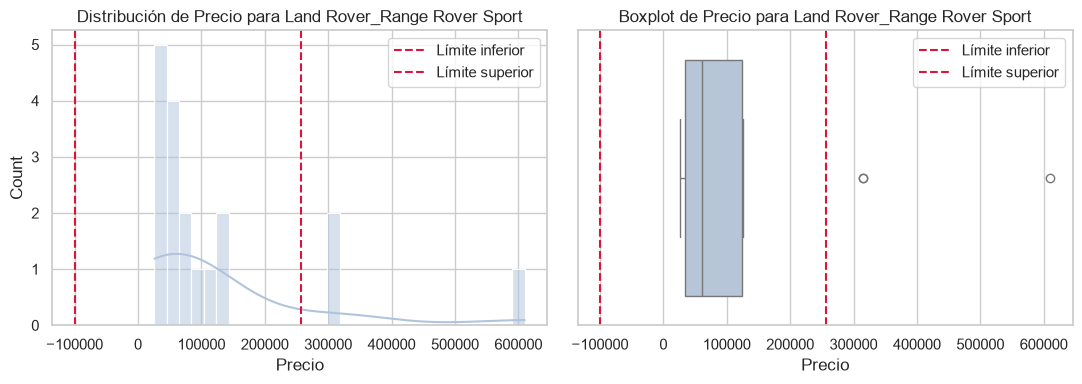

Renault_Duster — 1047 registros
Q1=11,940.30
Q3=17,304.90
IQR=5,364.61
Rango válido: [3,893.39, 25,351.81]
Outliers detectados: 89


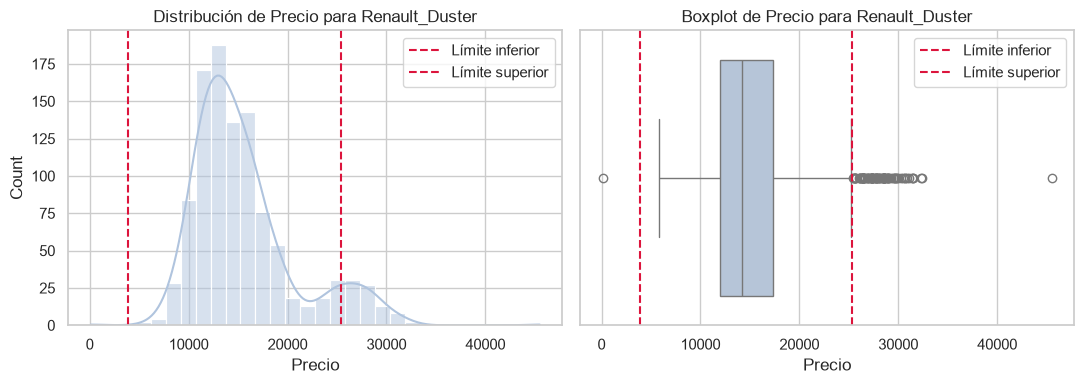

Jeep_Wrangler — 109 registros
Q1=38,500.00
Q3=90,000.00
IQR=51,500.00
Rango válido: [-38,750.00, 167,250.00]
Outliers detectados: 0


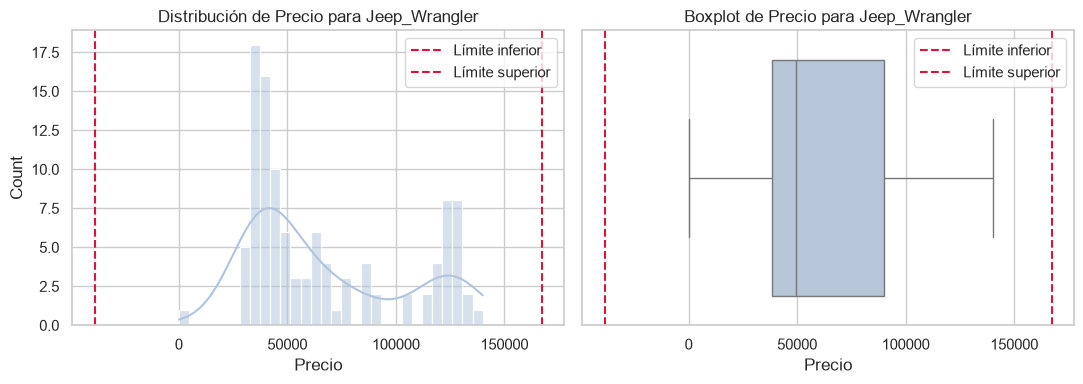

In [23]:
#Ejemplos especificos de Marca_Modelo con outliers
vista_outliers_marca = plot_grupo_especifico(df_outliers, grupo = "Land Rover_Range Rover Sport", k = 1.5)
vista_outliers_marca_= plot_grupo_especifico(df_outliers, grupo = "Renault_Duster", k = 1.5)
vista_outliers_marca_= plot_grupo_especifico(df_outliers, grupo = "Jeep_Wrangler", k = 1.5)

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
Lo que se logra notar es que hay precios < 5000 USD los cuales el IQR no logra detectar, por lo que se opta por eliminar estos casos para evitar outliers por Marca_Modelo.
</p>

In [24]:
len(df_outliers[df_outliers["Precio"] <= 5000])

25

##### Outliers en 'Kilometros'

In [25]:
display(data_pre[data_pre["Kilómetros"] > 500000]
    [["Marca_Modelo", "Precio", "Año", "Kilómetros"]]
    .sort_values("Kilómetros", ascending=False)
)

,Marca_Modelo,Precio,Año,Kilómetros
7614,Chevrolet_Blazer,7931.769723,2000.0,9999999.0
14106,Toyota_Hilux SW4,21748.400853,2009.0,1700000.0
16287,Nissan_Kicks,23027.718550,2020.0,1111111.0
14201,Peugeot_2008,18336.886994,2025.0,1111111.0
6479,Renault_Duster,7500.000000,2013.0,1111111.0
6109,Renault_Duster,12963.752665,2013.0,1111111.0
7156,Ford_Bronco,45000.000000,1981.0,1111111.0
11008,Suzuki_Jimny,11000.000000,1999.0,1111111.0
16688,Nissan_Kicks,23027.718550,2020.0,1111111.0
6118,Renault_Duster,14000.000000,2018.0,1111111.0


#### Creacion del dataset sin outliers

In [70]:
#Eliminar las muestras cuyo precio queda fuera del rango iqr correspondiente a su su marca_modelo
data_pre_sin_outliers= eliminar_outliers_grupo(df_outliers)
#Eliminar casos donde km >= 500000 
data_pre_sin_outliers = data_pre_sin_outliers [data_pre_sin_outliers["Kilómetros"] <= 500000].copy()

print("Original:", data_pre.shape)
print("\nIQR + Km limpio:", data_pre_sin_outliers.shape)

#Eliminar precio < 5000 USD
data_pre_final = eliminar_outliers_por_corte(
    data_pre_sin_outliers,
    precio_min=5000
)

print("\nDataset limpio final:", data_pre_final.shape)

Registros antes: 18205
Registros después: 17661
Eliminados: 544 (2.99%)
Original: (18205, 21)

IQR + Km limpio: (17224, 21)
Eliminados: 19 (0.11%)

Dataset limpio final: (17205, 21)


In [27]:
data_pre_final.to_csv("../data/processed/data_pre.csv", index=False)

**VISUALIZACION DEL EDA HASTA AHORA**

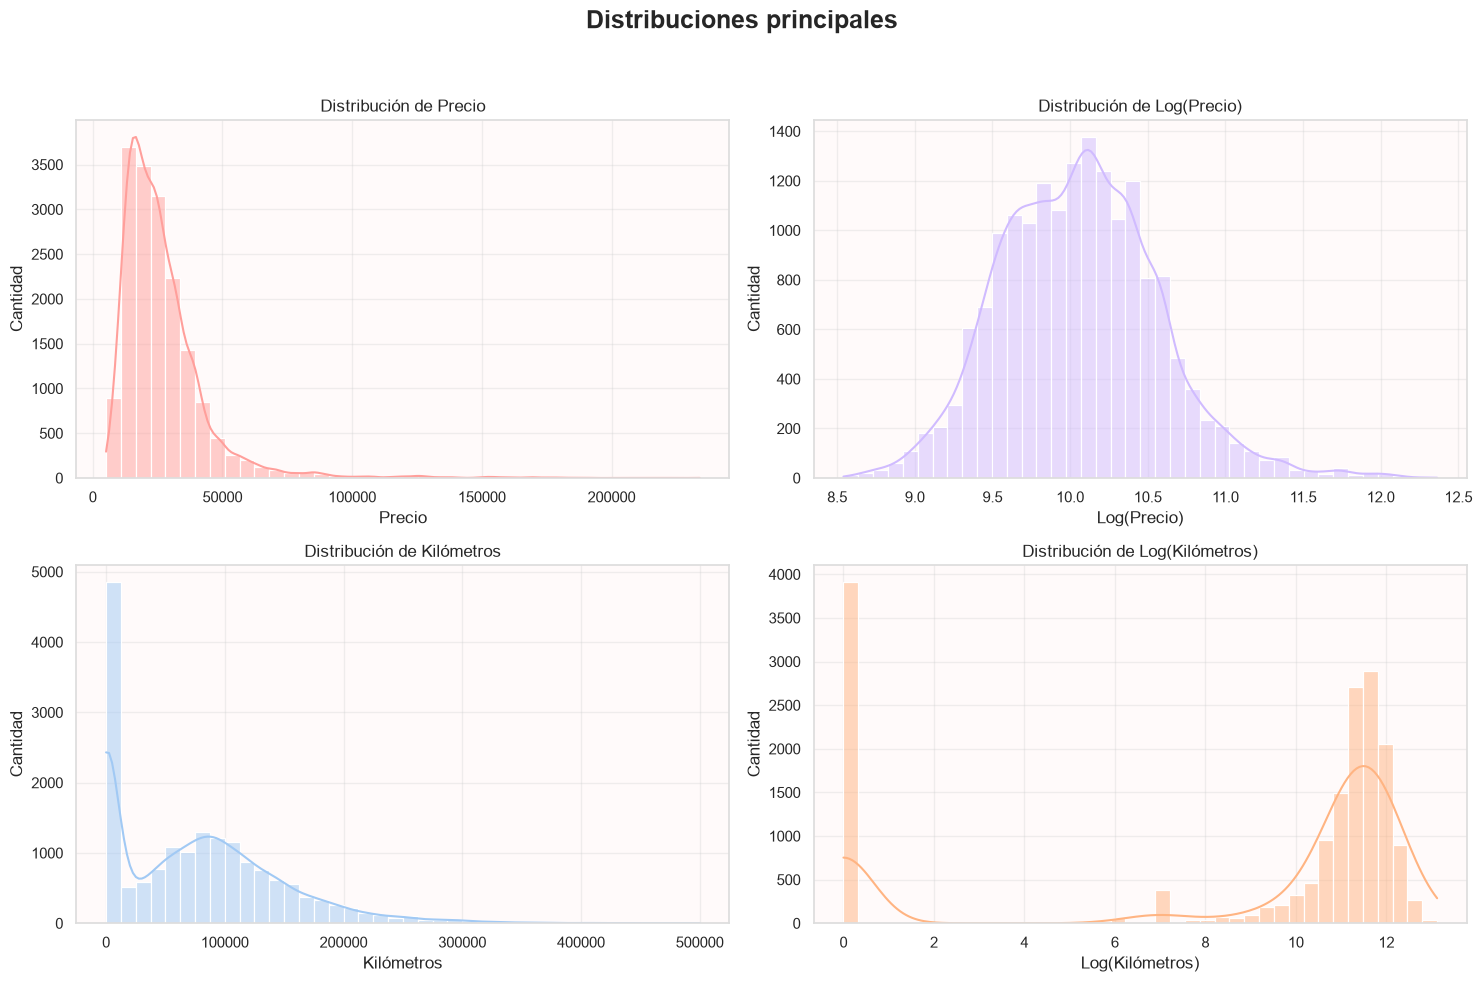

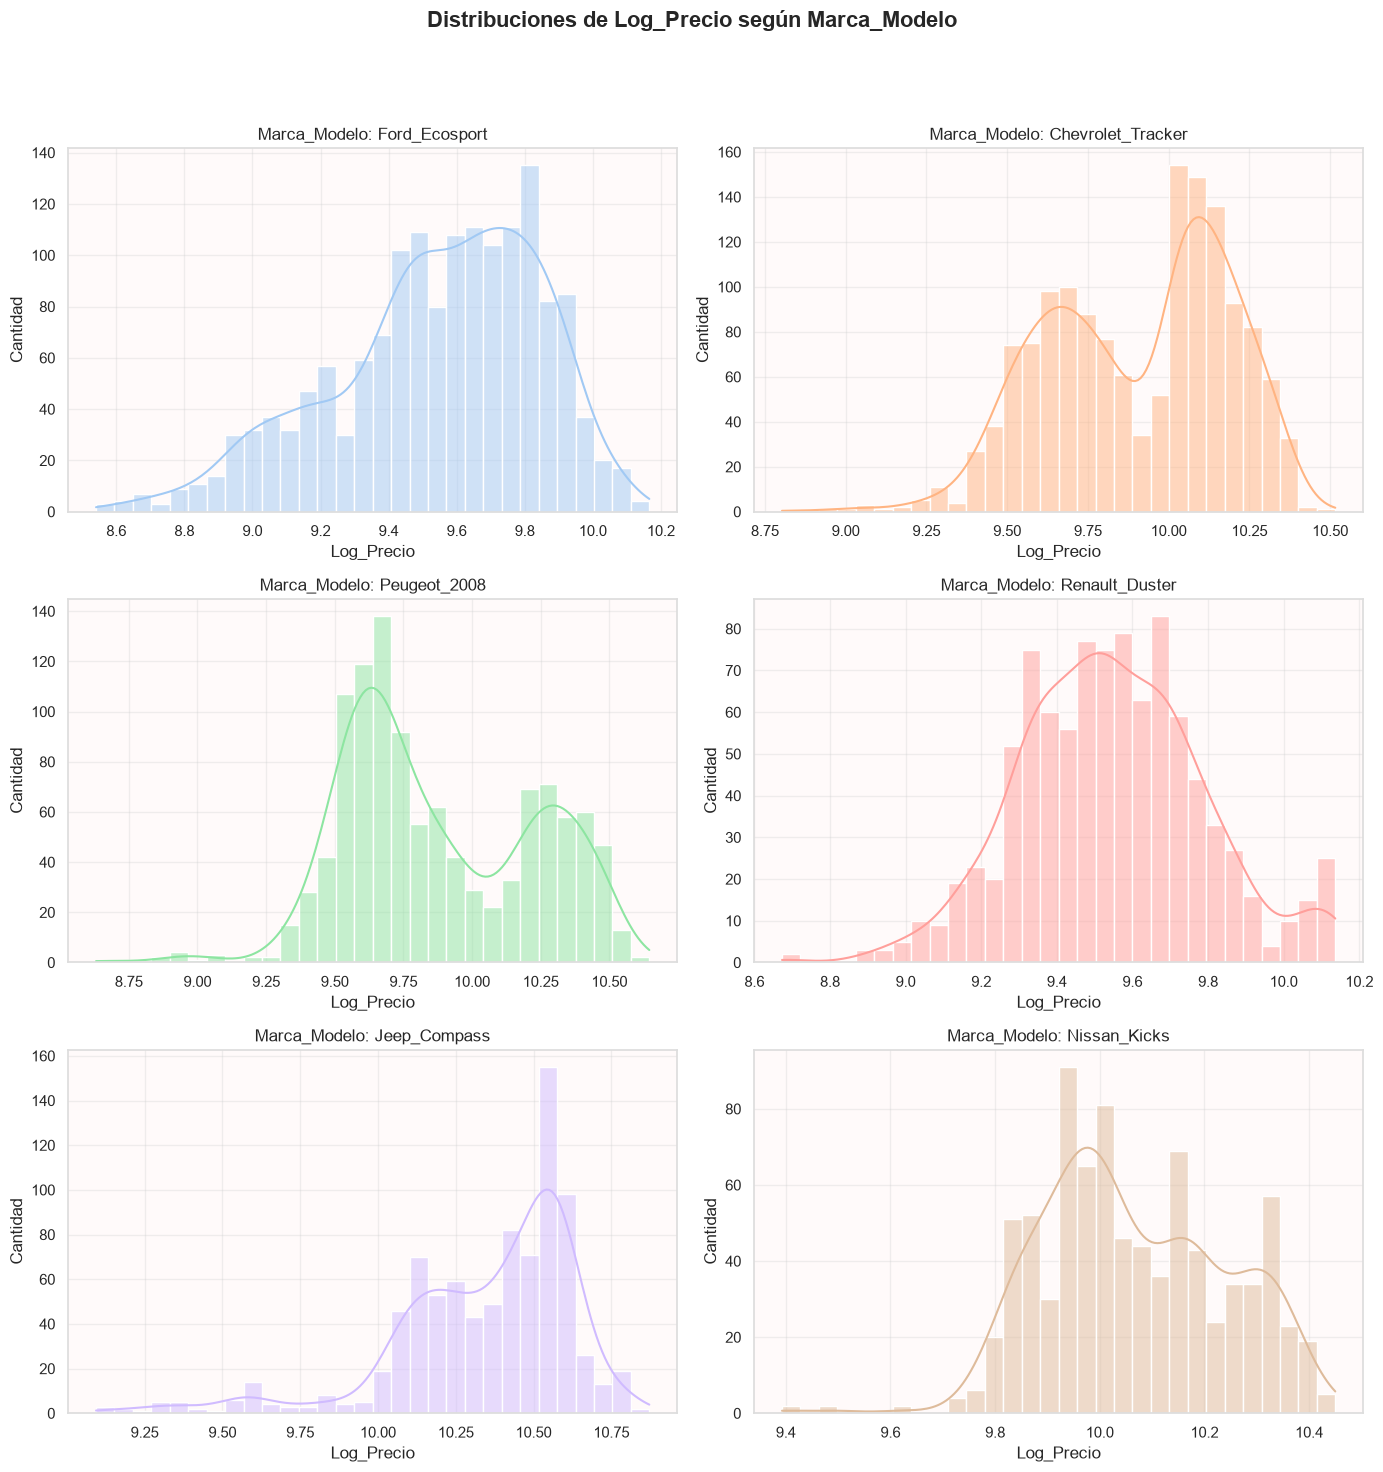

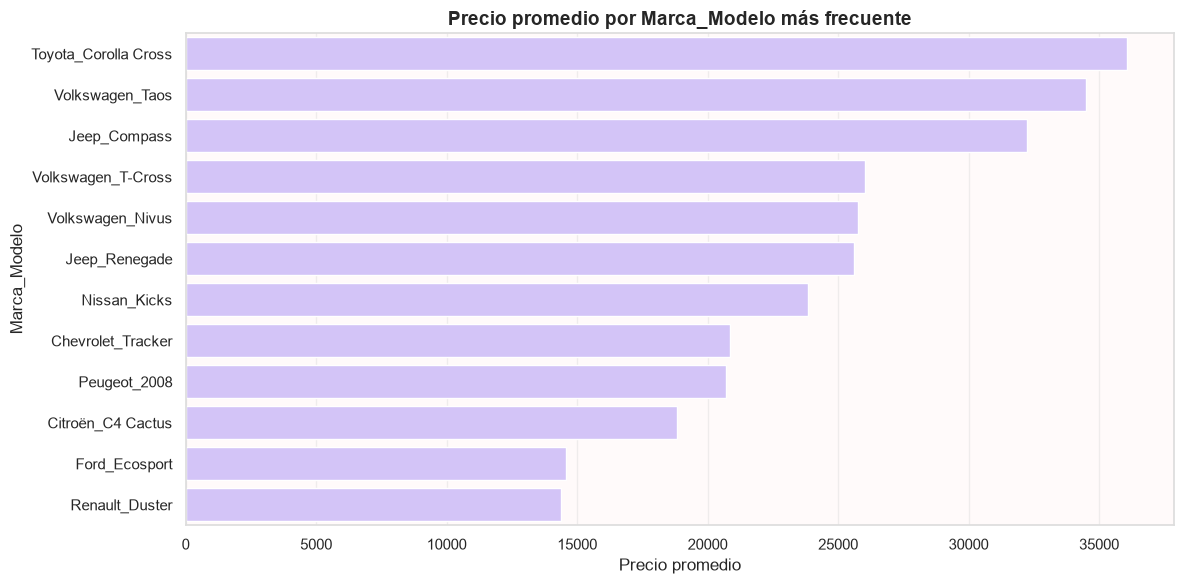

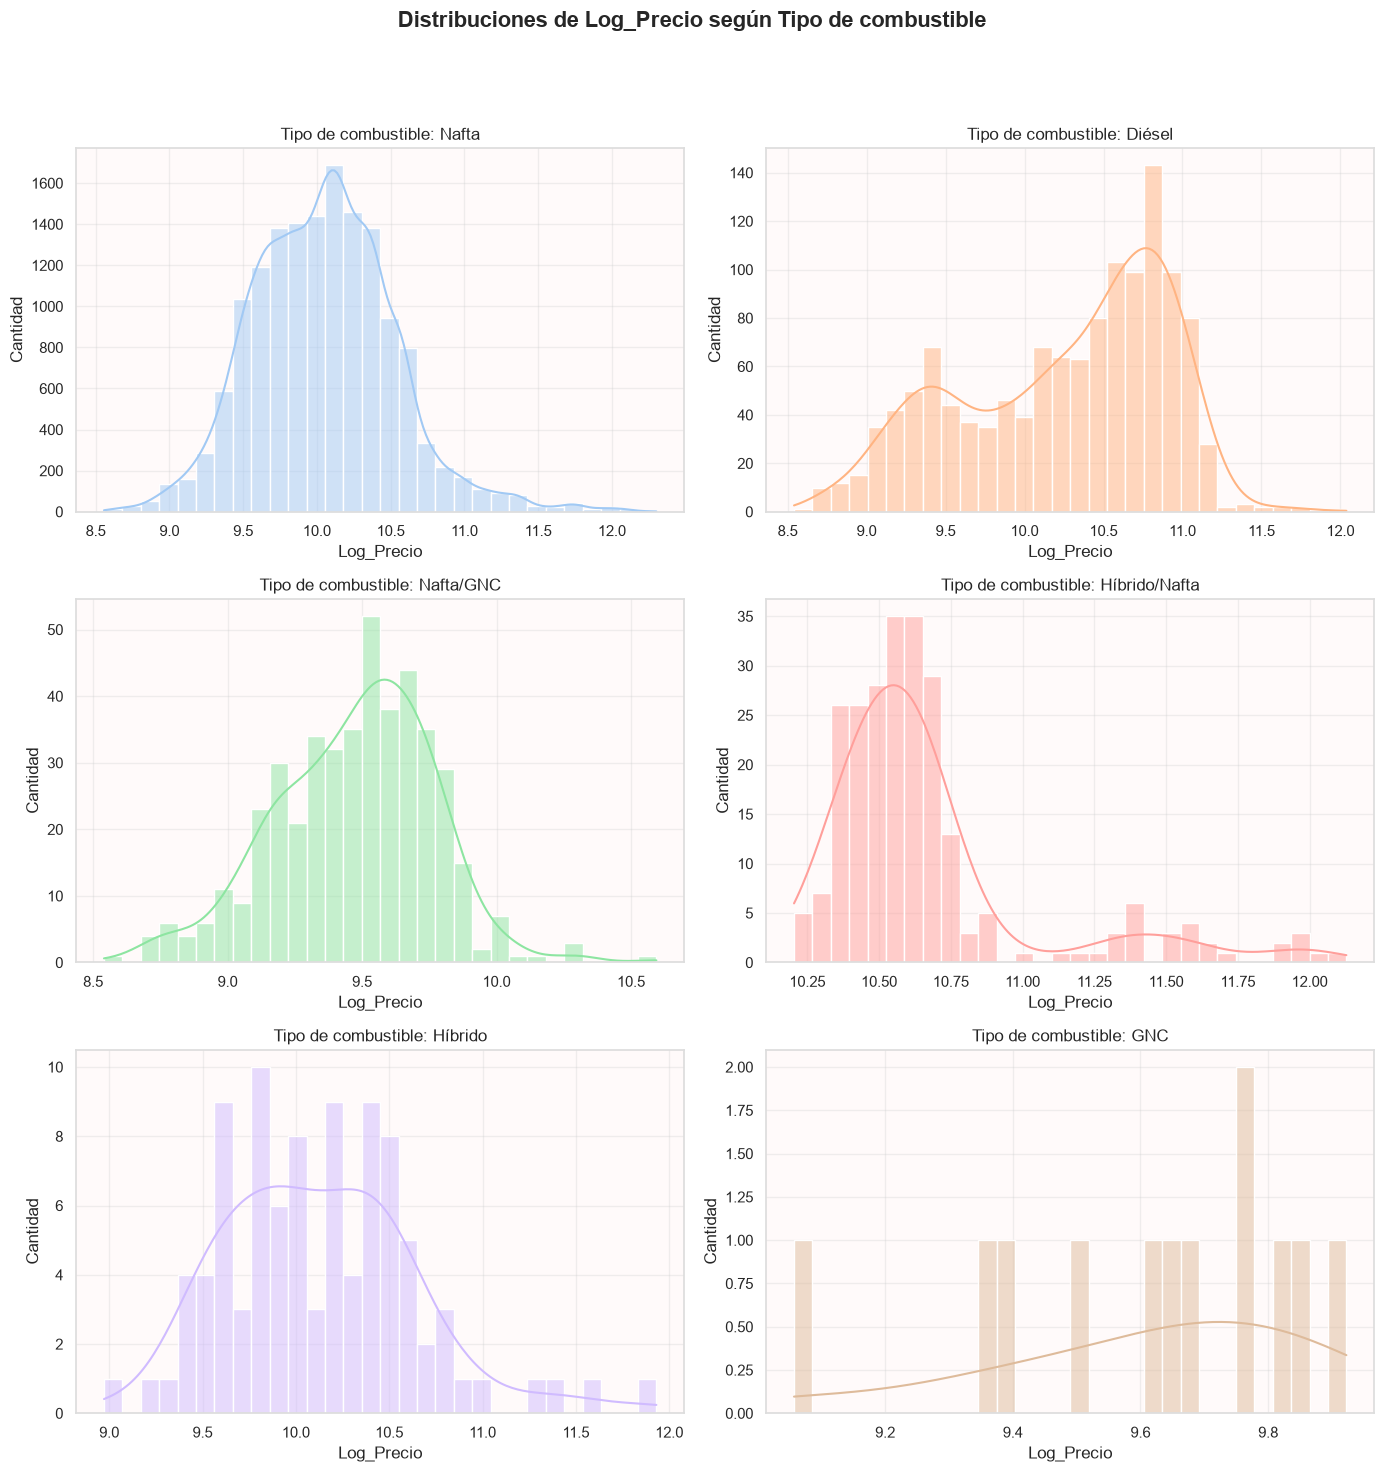

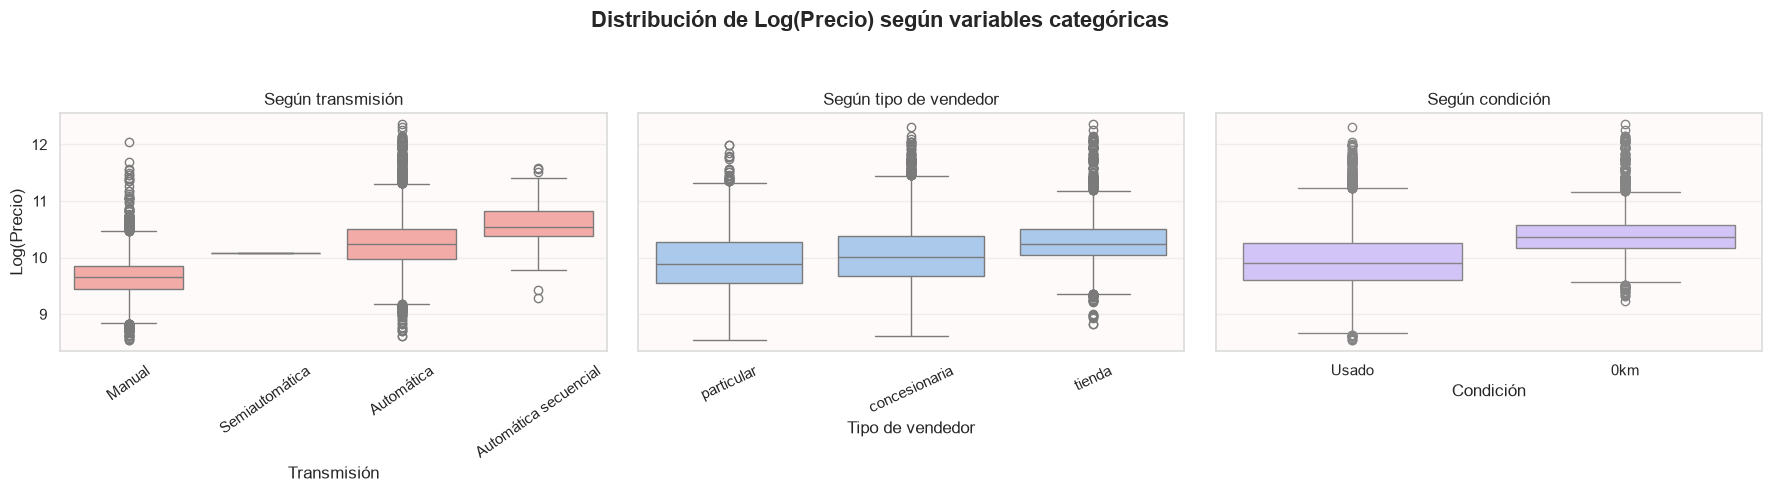

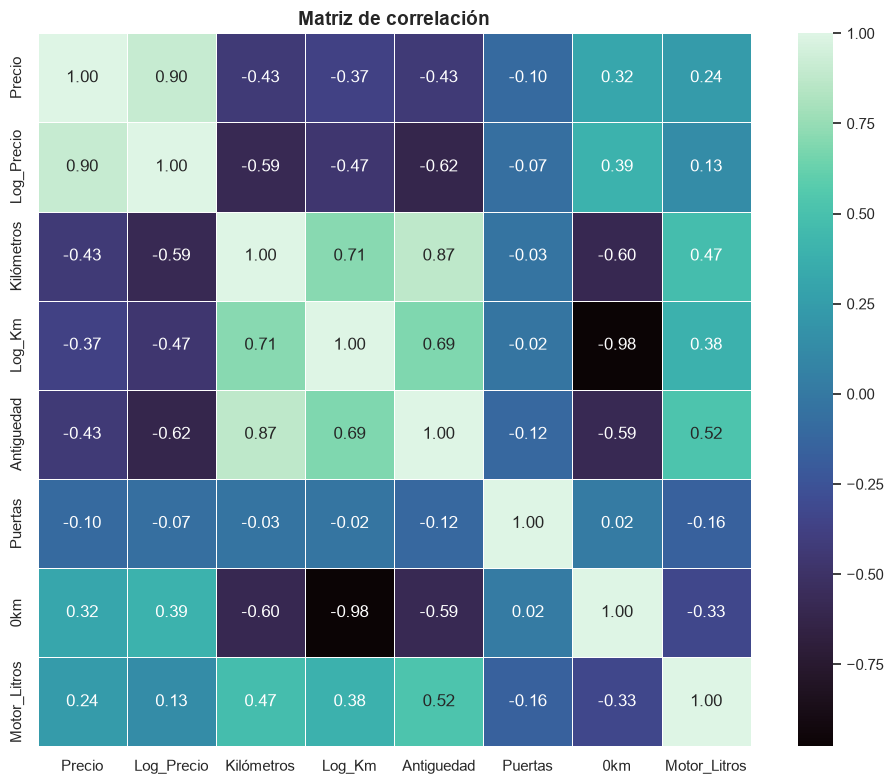

In [28]:
#Plots
eda_visualizacion_suvs(data_pre_final) 

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
<em>Se observan diferencias de precio según el modelo, el combustible y la condición del vehículo. Además, tanto el kilometraje como la antigüedad presentan una relación negativa con el precio. Las transformaciones logarítmicas permiten visualizar mejor estas relaciones al reducir la asimetría de las distribuciones originales.</em>
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
Para terminar con el <em><strong>preprocesamiento de datos</strong></em>, se aplica el split para poder obtener la moda calculada sobre el conjunto de train, y asi poder completar los valores faltantes de las features "Color", "Transmision", "Camara", "Kilómetros", "Motor_Litros" evitando el data leakage.
</p>

In [29]:
nulos = data_pre_final.isnull().sum()

if (nulos > 0).any():
    print("Columnas con NaN:")
    print(nulos[nulos > 0])
else:
    print("No quedan NaN en el dataset")

Columnas con NaN:
Color           360
Transmisión      10
Motor_Litros    392
dtype: int64


<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
11. <strong>Imputaciones realizadas después del split</strong>: todas las imputaciones basadas en estadísticas (moda o mediana) fueron calculadas exclusivamente sobre el conjunto de entrenamiento y posteriormente aplicadas al conjunto de validación, evitando data leakage.
</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
- <strong>Color</strong>: los valores faltantes se completaron utilizando la moda del color para cada vehículo (<code>Marca_Modelo</code>). Si un modelo no poseía suficientes observaciones, se utilizó la moda global del conjunto de entrenamiento.
</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
- <strong>Transmisión</strong>: debido a la baja cantidad de valores faltantes, se utilizó un imputador KNN entrenado sobre el conjunto de entrenamiento. La imputación se realizó considerando vehículos con características similares y posteriormente se reconstruyó la categoría original.
</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
- <strong>Kilómetros</strong>: los valores faltantes se completaron utilizando la mediana del kilometraje correspondiente al año del vehículo. En caso de no existir suficientes observaciones para un determinado año, se utilizó la mediana global del conjunto de entrenamiento.
</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
- <strong>Motor_Litros</strong>: cuando no fue posible recuperar la cilindrada a partir de la descripción original del motor, el valor faltante se imputó utilizando la mediana calculada sobre el conjunto de entrenamiento. Adicionalmente, se conservó la variable indicadora `Motor_Litros_Faltante` para que el modelo pudiera distinguir los registros originalmente incompletos.
</p>

*¿Hay alguna marca que tenga una menor dispersión en sus precios?*

In [30]:
#Definimos que las marcas con mas de 35 muestras sean las validas para calcular el Coeficiente de Variacion
marcas_validas = data_pre.copy()['Marca_Modelo'].str.split('_').str[0].value_counts()
marcas_validas = marcas_validas[marcas_validas >= 35].index

data_filtrado = data_pre.copy()
data_filtrado['Marca'] = data.copy()['Marca']
data_filtrado = data_filtrado[data_filtrado['Marca'].isin(marcas_validas)] 

cv = data_filtrado.groupby('Marca')['Precio'].agg(['std', 'mean'])
cv["cv"] = cv["std"] / cv["mean"]
cv.sort_values("cv")

,std,mean,cv
Marca,,,
BAIC,8140.985406,33488.199685,0.243100
Fiat,5623.258355,22573.266827,0.249111
Citroën,5356.622730,21299.147129,0.251495
Dodge,4096.793806,15005.480920,0.273020
Nissan,7386.615452,24177.944522,0.305510
Volkswagen,9946.490365,29356.175568,0.338821
Renault,5839.456744,16360.583504,0.356922
Peugeot,8283.403824,21760.351861,0.380665
Chevrolet,8881.018759,22681.389914,0.391555


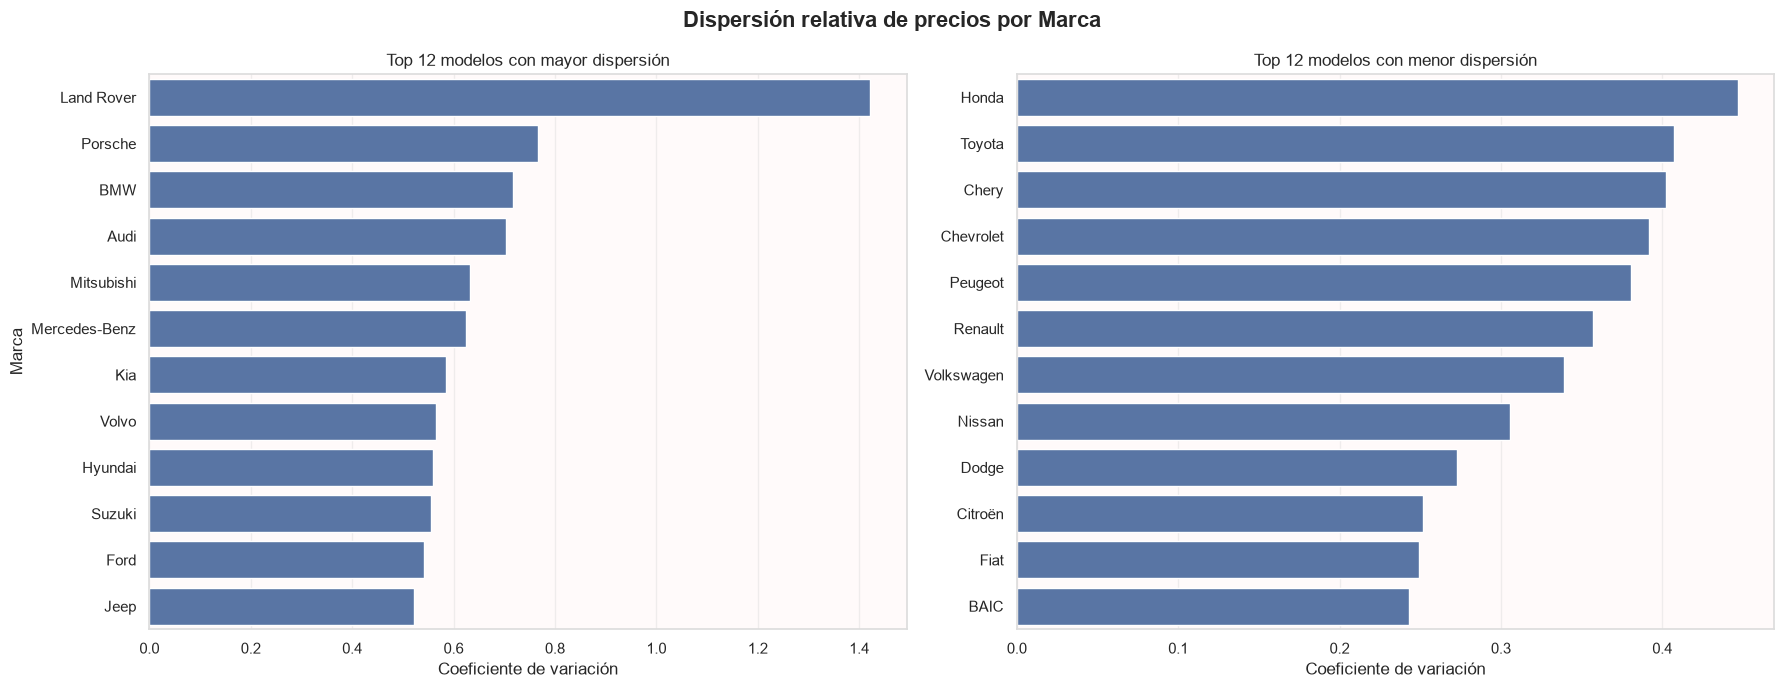

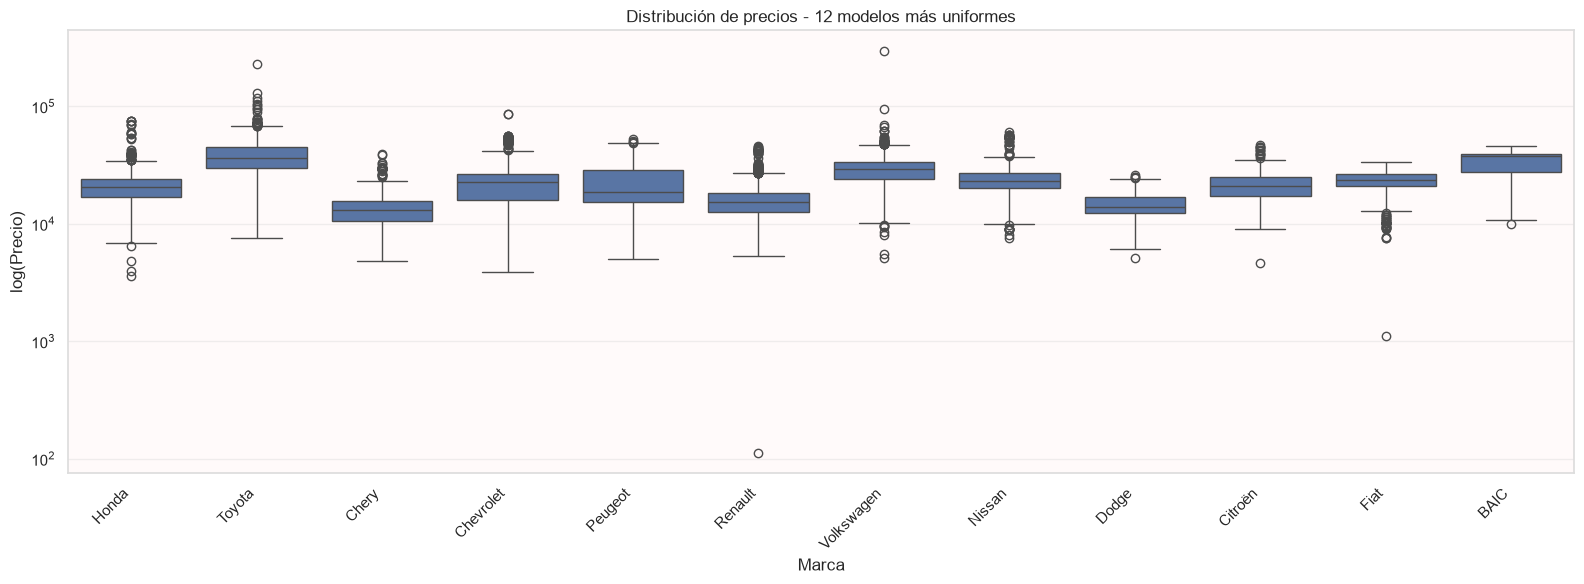

In [31]:
plot_dispersion_por_marca(data_filtrado, target = "Precio", min_muestras = 35, top_n = 12)

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Las marcas con mayor dispersión resultan ser <strong>Land Rover</strong>, <strong>Porsche</strong> y <strong>BMW</strong>, tres marcas de lujo, lo cual explica este resultado: ofrecen modelos que van desde vehículos de entrada hasta vehículos de alta gama, lo que genera una gran variabilidad de precios dentro de sus modelos. El boxplot confirma esto con cajas amplias (particularmente en el caso de Porsche) y outliers con valores extremos.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
En el extremo opuesto, encontramos a <strong>BAIC</strong>, <strong>Fiat</strong> y <strong>Citroën</strong>, que presentan la menor dispersión entre las marcas más predominantes del dataset. Se presentan como marcas con modelos más accesibles, los cuales se concentran en un rango de precio similar entre sí, y con un catálogo más acotado. Sus boxplots muestran cajas compactas y pocos outliers.
</p>
<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Lo observado a partir de la información provista coincide con lo esperable para este tipo de marcas, donde se tienen tanto modelos exclusivos como de segmento medio.
</p>

*¿Es más barato comprar un auto a un privado o a una concesionaria/tienda? De ser así, ¿cuál es la diferencia % de precio?*

In [32]:
mediana_por_vendedor = data_pre.groupby('Tipo de vendedor')['Precio'].median()
mediana_particulares = mediana_por_vendedor['particular']

valores = ((mediana_por_vendedor - mediana_particulares) / mediana_particulares * 100).round(2)

display(pd.DataFrame({
    'Tipo de vendedor': valores.index,
    'Diferencia respecto a particular': valores.values.round(2).astype(str) + '%'}))

,Tipo de vendedor,Diferencia respecto a particular
0,concesionaria,16.09%
1,particular,0.0%
2,tienda,43.89%


<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
Se definio la mediana de los precios de los vendedores particulares como la base para la comparacion, razon por la cual se tiene que su valor porcentual es del 0.0%. Los resultados muestran que tanto las concesionarias como las tiendas publican sus vehiculos a precios superiores, siendo estas ultimas las que mayor sobreprecio presentan respecto de los privados. Esto refleja como los costos adicionales que incluyen estos canales tales como garantias y/o tipos de financiacion, afectan sus precios de venta. Más coloquialmente, el precio propuesto por las tiendas es equivalente a la compra de 1 auto y práticamente la mitad de otro.
</p>

In [33]:
train, val = train_val_split(data_pre_final)

Tamaño conjunto de entrenamiento -> (13764, 21), 
Tamaño conjunto de validación -> (3441, 21)


In [34]:
#Preprocessing post split usando los parametros del entrenamiento
X_train, X_val = preprocesamiento_post_split(train, val)

In [35]:
#One-Hot Encoding sobre las columnas con baja cardinalidad
columnas_oh = ["Marca_Modelo","Color",'Tipo de combustible', 'Tipo de vendedor', 'Transmisión', 'Con cámara de retroceso']
X_train_final, X_val_final = onehot_encoding(X_train, X_val, columnas_oh)

*¿Hay un ranking de colores de autos en cuanto a precio? ¿Cuál es el precio relativo de un los distintos colores?*

In [36]:
data_unificado = pd.concat([X_train, X_val]).reset_index(drop = True)

mediana_general = data_unificado['Precio'].median()

precio_por_color = data_unificado.groupby('Color')['Precio'].median().sort_values(ascending = False)
precio_relativo = ((precio_por_color - mediana_general) / mediana_general * 100).round(2)

display(pd.DataFrame({
    'Color': precio_por_color.index,
    'Mediana por color (USD)': precio_por_color.values,
    'Diferencia respecto a la mediana general': precio_relativo.values.round(2).astype(str) + '%'}))

,Color,Mediana por color (USD),Diferencia respecto a la mediana general
0,rosa,31803.837953,38.11%
1,amarillo,25031.982942,8.7%
2,gris,24800.000000,7.7%
3,azul,24307.036247,5.56%
4,blanco,23880.597015,3.7%
5,otro,22686.567164,-1.48%
6,bordó,21748.400853,-5.56%
7,plateado,21500.000000,-6.63%
8,negro,21321.961620,-7.41%
9,rojo,20042.643923,-12.96%


<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
Con esta tabla en consideracion, podemos ver que la existencia de un ranking de colores en cuanto a su precio es real. De esta forma, vehículos con colores menos frecuentes, tales como el <em>rosa</em> y el <em>amarillo</em> son los que presentan la mayor diferencia en cuanto a la mediana general de los precios. En el extremo opuesto, se tienen al <em>verde</em> y <em>dorado</em>, con una diferencia negativa, demostrando que sus precios estan porcentualmente debajo de los generales. Los colores mas comunes como el <em>gris</em>, <em>blanco</em> y <em>negro</em> se mantienen cercanos a la mediana general. Estas diferencias sugieren que el color está correlacionado con el segmento del vehículo: colores como el <em>rosa</em> y el <em>amarillo</em> tienden a aparecer en modelos deportivos o de lujo, mientras que colores atípicos como el <em>verde</em> 
se asocian a vehículos más antiguos o de menor valor de mercado.
</p>

*¿Cuál es el efecto de los años de uso y el kilometraje sobre el precio de un auto?*

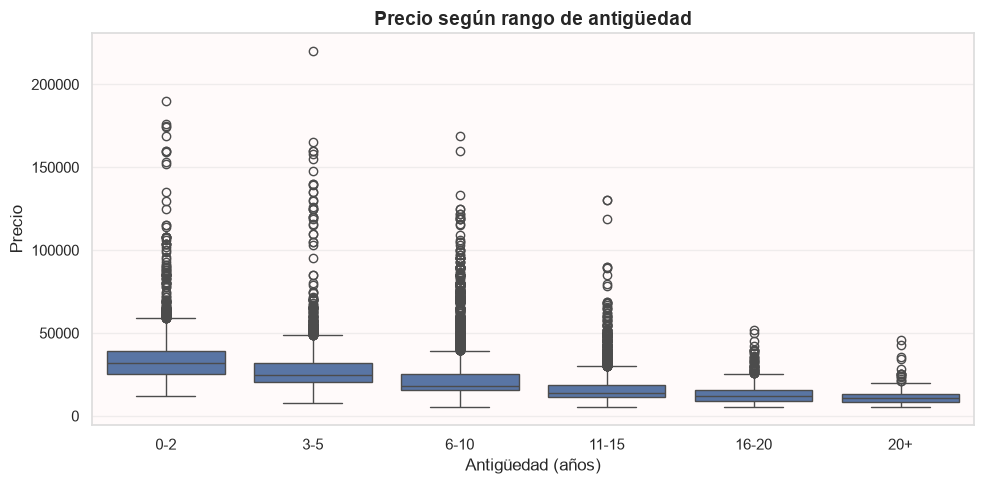

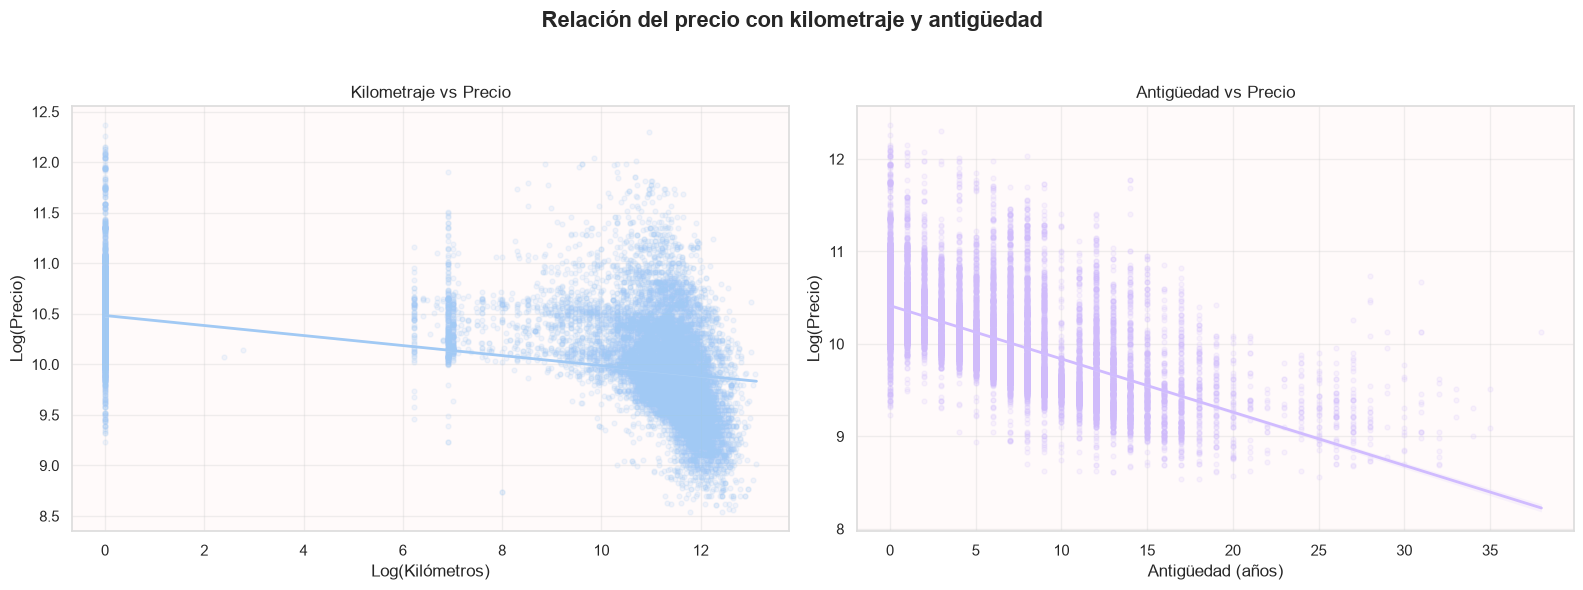

In [37]:
data_visualizacion = pd.concat([X_train_final, X_val_final], ignore_index = True)
data_visualizacion = data_visualizacion[data_visualizacion["Antiguedad"] <= 50]
plot_precio_segun_rango_ant(data_visualizacion)
plot_precio_segun_antiguedad_km(data_visualizacion)

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Podemos observar, tanto para la <strong>antigüedad</strong> como para el <strong>kilometraje</strong> (plot presentado en la seccion <em>Visualizacion EDA hasta ahora</em>) una clara tendencia. El primer gráfico muestra que a mayor años de uso, el precio del vehículo (en escala logarítmica) decrece de manera consistente. Los autos de 0-2 años concentran los precios más altos, rondando entre los e^10 y e^12 USD, mientras que los de más de 20 años, se ubican en rangos más bajos.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
El segundo gráfico confirma lo esperado: a mayor log(Km), menor log(Precio). Los vehículos 0km tienen precios más elevados, lo cual es consistente con la realidad; y la dispersión aumenta a medida que sube el kilometraje, lo que genera el desgaste del vehículo, impactando negativamente en su precio.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
El boxplot por rangos de antiguedad refuerza ambas observaciones: la mediana de precio decae progresivamente, reduciéndose la dispersión en autos más antiguos. Los outliers más extremos se localizan en el rango de los 0-2 años, correspondiendo posiblemente, a vehículos de alta gama 0km.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Con esto se deja en evidencia la importancia de ambos features en relación con el precio para la generalización del modelo predictivo a entrenar.
</p>

In [38]:
print('Tamaño train final -> ', X_train_final.shape)
print('Tamaño val final -> ', X_val_final.shape)

Tamaño train final ->  (13764, 215)
Tamaño val final ->  (3441, 215)


In [39]:
#Cargar el set de entrenamiento y validación a csv para observar los cambios
X_train_final.to_csv("../data/processed/X_train_EDA.csv", index = False)
X_val_final.to_csv("../data/processed/X_val_EDA.csv", index = False)

### **MODELOS**

<p style="text-align: justify; text-justify: inter-word; font-size: 17px;">
Para el desarrollo de los modelos, optamos por analizar 2 casos: considerando el TF-IDF sobre la variable de Descripcion y, el extremo opuesto, eliminando esta columna. Esto se realizo con el objetivo de analizar la incidencia de este feature en la prediccion de los precios.
</p>

In [40]:
#Sin variables categóricas, considerando OHE
X_train_ohe = X_train_final.drop(columns = ['Precio'])
y_train_ohe = X_train_final['Precio']

X_val_ohe = X_val_final.drop(columns = ['Precio'])
y_val_ohe = X_val_final['Precio']

In [41]:
#Estandarización
#Con 'Descripción'
X_train_array, X_val_array, _, _ = estandarizar(X_train_ohe.values, X_val_ohe.values)
X_train_ohe_estandarizado = pd.DataFrame(X_train_array, columns = X_train_ohe.columns)
X_val_ohe_estandarizado = pd.DataFrame(X_val_array, columns = X_val_ohe.columns)

#Sin 'Descripción'
columnas = [col for col in X_train_ohe_estandarizado.columns if col.startswith('Descripcion_')]
X_train_no_desc = X_train_ohe_estandarizado.drop(columns = columnas)
X_val_no_desc = X_val_ohe_estandarizado.drop(columns = [col for col in X_val_ohe_estandarizado.columns if col.startswith('Descripcion_')])

#### **Regresion Lineal** 

##### **Regresion sin regularizacion (modelo baseline)**

In [42]:
#Con TF-IDF sobre 'Descripción'
modelo_rl_base, predicciones_rl_base, rmse_rl_base, mae_rl_base, r2_rl_base = entrenar_regresion_lineal(X_train_ohe_estandarizado, y_train_ohe, X_val_ohe_estandarizado, y_val_ohe)

#Sin TF-IDF sobre 'Descripción'
modelo_rl_base_no_desc, predicciones_rl_base_no_desc, rmse_rl_base_no_desc, mae_rl_base_no_desc, r2_rl_base_no_desc = entrenar_regresion_lineal(X_train_no_desc, y_train_ohe, X_val_no_desc, y_val_ohe)

In [71]:
print(f'RL baseline - Con TF-IDF sobre Descripcion -> RMSE (USD) = {rmse_rl_base:.4f}')
print(f'RL baseline - Sin TF-IDF sobre Descripcion -> RMSE (USD) = {rmse_rl_base_no_desc:.4f}')

RL baseline - Con TF-IDF sobre Descripcion -> RMSE (USD) = 6261.7482
RL baseline - Sin TF-IDF sobre Descripcion -> RMSE (USD) = 6350.9429


In [72]:
#Busqueda de lambdas para regularizacion
print(f'Busqueda parametro de regularizacion')
lambdas = [0.1, 0.5, 1.0, 10.0]

#Con TF-IDF sobre 'Descripción'
resultados_tfidf = definir_regularizacion(X_train_ohe_estandarizado, y_train_ohe, X_val_ohe_estandarizado, y_val_ohe, lambdas)
print(f"RL regularizada - Con TF-IDF sobre Descripcion -> mejor RMSE (USD): {resultados_tfidf['RMSE'].min():.4f}")

#Sin TF-IDF sobre 'Descripción'
resultados_no_desc = definir_regularizacion(X_train_no_desc, y_train_ohe, X_val_no_desc, y_val_ohe, lambdas)
print(f"RL regularizada - SIN TF-IDF sobre Descripcion -> mejor RMSE (USD): {resultados_no_desc['RMSE'].min():.4f}")

Busqueda parametro de regularizacion
RL regularizada - Con TF-IDF sobre Descripcion -> mejor RMSE (USD): 6260.4081
RL regularizada - SIN TF-IDF sobre Descripcion -> mejor RMSE (USD): 6349.7729


In [45]:
print('Resultados ordenados por RMSE considerando TF-IDF sobre Descripción')
display(resultados_tfidf.iloc[:5])
print('Resultados ordenados por RMSE sin considerar TF-IDF sobre Descripción')
display(resultados_no_desc[:5])

Resultados ordenados por RMSE considerando TF-IDF sobre Descripción


,Modelo,Lambda,RMSE,MAE,R2
5,Lasso,1.0,6260.408140,3744.407257,0.850344
3,Lasso,0.5,6260.486509,3745.898864,0.850340
1,Lasso,0.1,6260.597131,3747.142136,0.850335
0,Ridge,0.1,6261.759016,3747.938061,0.850279
2,Ridge,0.5,6261.802778,3747.792713,0.850277


Resultados ordenados por RMSE sin considerar TF-IDF sobre Descripción


,Modelo,Lambda,RMSE,MAE,R2
5,Lasso,1.0,6349.772910,3752.715017,0.846041
3,Lasso,0.5,6349.904806,3754.328408,0.846035
1,Lasso,0.1,6350.005475,3755.570736,0.846030
0,Ridge,0.1,6350.954445,3756.352051,0.845984
2,Ridge,0.5,6351.000887,3756.209359,0.845981


In [46]:
#ELIGE EL MENOR RMSE Y GUARDA BIEN LOS MODELOS 

mejor_tfidf = resultados_tfidf.iloc[0]
mejor_no_desc = resultados_no_desc.iloc[0]

mejor_rl_config = mejor_tfidf if mejor_tfidf["RMSE"] < mejor_no_desc["RMSE"] else mejor_no_desc

mejor_X_train = X_train_ohe_estandarizado if mejor_tfidf["RMSE"] < mejor_no_desc["RMSE"] else X_train_no_desc
mejor_X_val = X_val_ohe_estandarizado if mejor_tfidf["RMSE"] < mejor_no_desc["RMSE"] else X_val_no_desc
mejor_y_train = y_train_ohe
mejor_y_val = y_val_ohe

if mejor_rl_config["Modelo"] == "Ridge":
    mejor_rl = Ridge(alpha=mejor_rl_config["Lambda"], solver="svd")
else:
    mejor_rl = Lasso(alpha=mejor_rl_config["Lambda"], max_iter=50000)

if mejor_no_desc["Modelo"] == "Ridge":
    rl_no_desc = Ridge(alpha=mejor_no_desc["Lambda"], solver="svd")
else:
    rl_no_desc = Lasso(alpha=mejor_no_desc["Lambda"], max_iter=50000)

modelo_rl_final, predicciones_rl_final, rmse_rl_final, mae_rl_final, r2_rl_final = entrenar_regresion_lineal(
    mejor_X_train,
    mejor_y_train,
    mejor_X_val,
    mejor_y_val,
    modelo=mejor_rl
)

modelo_rl_no_desc_final, predicciones_rl_no_desc_final, rmse_rl_no_desc_final, mae_rl_no_desc_final, r2_rl_no_desc_final = entrenar_regresion_lineal(
    X_train_no_desc,
    y_train_ohe,
    X_val_no_desc,
    y_val_ohe,
    modelo=rl_no_desc
)

In [47]:
resumen_rl_train_val = pd.DataFrame([
    {
        "Modelo": "RL Base - Con TF-IDF",
        **metricas_train_val(
            modelo_rl_base,
            X_train_ohe_estandarizado,
            y_train_ohe,
            X_val_ohe_estandarizado,
            y_val_ohe
        )
    },
    {
        "Modelo": "RL Base - Sin TF-IDF",
        **metricas_train_val(
            modelo_rl_base_no_desc,
            X_train_no_desc,
            y_train_ohe,
            X_val_no_desc,
            y_val_ohe
        )
    },
    {
        "Modelo": f"RL {mejor_rl_config['Modelo']} (λ={mejor_rl_config['Lambda']}) - Mejor versión",
        **metricas_train_val(
            modelo_rl_final,
            mejor_X_train,
            mejor_y_train,
            mejor_X_val,
            mejor_y_val
        )
    },
    {
        "Modelo": f"RL {mejor_no_desc['Modelo']} (λ={mejor_no_desc['Lambda']}) - Sin TF-IDF",
        **metricas_train_val(
            modelo_rl_no_desc_final,
            X_train_no_desc,
            y_train_ohe,
            X_val_no_desc,
            y_val_ohe
        )
    }
])

display(
    resumen_rl_train_val
    .sort_values("RMSE Val")
    .style.format({
        "RMSE Train": "{:.2f}",
        "RMSE Val": "{:.2f}",
        "MAE Train": "{:.2f}",
        "MAE Val": "{:.2f}",
        "R² Train": "{:.4f}",
        "R² Val": "{:.4f}",
    })
)

,Modelo,RMSE Train,RMSE Val,MAE Train,MAE Val,R² Train,R² Val
2,RL Lasso (λ=1.0) - Mejor versión,6702.48,6260.41,3862.17,3744.41,0.8481,0.8503
0,RL Base - Con TF-IDF,6702.37,6261.75,3865.23,3747.98,0.8481,0.8503
3,RL Lasso (λ=1.0) - Sin TF-IDF,6774.42,6349.77,3866.51,3752.72,0.8448,0.8460
1,RL Base - Sin TF-IDF,6774.31,6350.94,3869.44,3756.39,0.8448,0.8460


#### **XGBoost**

In [48]:
grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [4,6,8],
    'learning_rate': [0.05, 0.1, 0.5] 
    }

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Dado que XGBoost soporta de manera nativa variables categoricas, estableciendo <code>enable_categorical = True</code>, se desarrollaron 2 arboles: el primero considerando esta opcion, mientras que el segundo utilizo el dataset donde a las variables categoricas se les aplico One-Hot Encoding.

A su vez, los arboles son invariantes a la escala de los features, razon por la cual no se estandarizan.
</p>

In [49]:
#DATASETS CON FEATURES CATEGORICAS
#Con variables categoricas
X_train_xgboost = X_train.drop(columns = ['Precio'])
y_train_xgboost = train['Precio']

X_val_xgboost = X_val.drop(columns = ['Precio'])
y_val_xgboost = val['Precio']

#Sin TF-IDF sobre 'Descripción'
X_train_xgboost_no_desc = X_train_xgboost.drop(columns = columnas)
X_val_xgboost_no_desc = X_val_xgboost.drop(columns = columnas)

In [50]:
#Con TF-IDF - Grid search categorico
resultados_gs_categorico = grid_search(X_train_xgboost, y_train_xgboost, n_estimators_list = grid['n_estimators'], max_depth_list = grid['max_depth'], learning_rate_list = grid['learning_rate'])

#Sin TF-IDF - Grid search categorico
resultados_gs_categorico_no_desc = grid_search(X_train_xgboost_no_desc, y_train_xgboost, n_estimators_list = grid['n_estimators'], max_depth_list = grid['max_depth'], learning_rate_list = grid['learning_rate'])

In [51]:
#Con TF-IDF - Grid search OHE
resultados_gs_ohe = grid_search(X_train_ohe, y_train_xgboost, n_estimators_list = grid['n_estimators'], max_depth_list = grid['max_depth'], learning_rate_list = grid['learning_rate'], categorico = False)

#Sin TF-IDF - Grid search OHE
X_train_ohe_no_desc = X_train_ohe.drop(columns = columnas)
X_val_ohe_no_desc = X_val_ohe.drop(columns = columnas)
resultados_gs_ohe_no_desc = grid_search(X_train_ohe_no_desc, y_train_xgboost, n_estimators_list = grid['n_estimators'], max_depth_list = grid['max_depth'], learning_rate_list = grid['learning_rate'], categorico = False)

In [52]:
#Guardamos los mejores resultados
mejor_combinacion_categorico = resultados_gs_categorico.iloc[0]
mejor_combinacion_categorico_no_desc = resultados_gs_categorico_no_desc.iloc[0]
mejor_combinacion_ohe = resultados_gs_ohe.iloc[0]
mejor_combinacion_ohe_no_desc = resultados_gs_ohe_no_desc.iloc[0]

In [53]:
#Entrenamos el mejor modelo para cada caso: Con y Sin TF-IDF y variables categoricas, con y sin TF-IDF con ohe sobre las variables categoricas
#-> Con TF-IDF sobre Descripcion y variables categoricas
modelo_categorico_final, prediccion_categorico_final, rmse_categorico_final, mae_categorico_final, r2_categorico_final = entrenar_xgboost(X_train_xgboost, y_train_xgboost, X_val_xgboost, y_val_xgboost, n_estimators = int(mejor_combinacion_categorico['n_estimators']), max_depth = int(mejor_combinacion_categorico['max_depth']), learning_rate = mejor_combinacion_categorico['learning_rate'])
#-> Sin TF-IDF sobre Descripcion y variables categoricas
modelo_categorico_final_no_desc, prediccion_categorico_final_no_desc, rmse_categorico_final_no_desc, mae_categorico_final_no_desc, r2_categorico_final_no_desc = entrenar_xgboost(X_train_xgboost_no_desc, y_train_xgboost, X_val_xgboost_no_desc, y_val_xgboost, n_estimators = int(mejor_combinacion_categorico_no_desc['n_estimators']), max_depth = int(mejor_combinacion_categorico_no_desc['max_depth']), learning_rate = mejor_combinacion_categorico_no_desc['learning_rate'])
#-> Con TF-IDF sobre Descripcion y OHE
modelo_ohe_final, prediccion_ohe_final, rmse_ohe_final, mae_ohe_final, r2_ohe_final = entrenar_xgboost_ohe(X_train_ohe, y_train_xgboost, X_val_ohe, y_val_xgboost, n_estimators = int(mejor_combinacion_ohe['n_estimators']), max_depth = int(mejor_combinacion_ohe['max_depth']), learning_rate = mejor_combinacion_ohe['learning_rate'])
#-> Sin TF-IDF sobre Descripcion y OHE
modelo_ohe_final_no_desc, prediccion_ohe_final_no_desc, rmse_ohe_final_no_desc, mae_ohe_final_no_desc, r2_ohe_final_no_desc = entrenar_xgboost_ohe(X_train_ohe_no_desc, y_train_xgboost, X_val_ohe_no_desc, y_val_xgboost, n_estimators = int(mejor_combinacion_ohe_no_desc['n_estimators']), max_depth = int(mejor_combinacion_ohe_no_desc['max_depth']), learning_rate = mejor_combinacion_ohe_no_desc['learning_rate'])

In [54]:
resumen_xgb_train_val = pd.DataFrame([
    {
        "Modelo": "XGBoost Categórico - Con TF-IDF",
        "n_estimators": int(mejor_combinacion_categorico["n_estimators"]),
        "max_depth": int(mejor_combinacion_categorico["max_depth"]),
        "learning_rate": mejor_combinacion_categorico["learning_rate"],
        **metricas_train_val(
            modelo_categorico_final,
            X_train_xgboost,
            y_train_xgboost,
            X_val_xgboost,
            y_val_xgboost,
            categorico=True
        )
    },
    {
        "Modelo": "XGBoost Categórico - Sin TF-IDF",
        "n_estimators": int(mejor_combinacion_categorico_no_desc["n_estimators"]),
        "max_depth": int(mejor_combinacion_categorico_no_desc["max_depth"]),
        "learning_rate": mejor_combinacion_categorico_no_desc["learning_rate"],
        **metricas_train_val(
            modelo_categorico_final_no_desc,
            X_train_xgboost_no_desc,
            y_train_xgboost,
            X_val_xgboost_no_desc,
            y_val_xgboost,
            categorico=True
        )
    },
    {
        "Modelo": "XGBoost OHE - Con TF-IDF",
        "n_estimators": int(mejor_combinacion_ohe["n_estimators"]),
        "max_depth": int(mejor_combinacion_ohe["max_depth"]),
        "learning_rate": mejor_combinacion_ohe["learning_rate"],
        **metricas_train_val(
            modelo_ohe_final,
            X_train_ohe,
            y_train_xgboost,
            X_val_ohe,
            y_val_xgboost,
            categorico=False
        )
    },
    {
        "Modelo": "XGBoost OHE - Sin TF-IDF",
        "n_estimators": int(mejor_combinacion_ohe_no_desc["n_estimators"]),
        "max_depth": int(mejor_combinacion_ohe_no_desc["max_depth"]),
        "learning_rate": mejor_combinacion_ohe_no_desc["learning_rate"],
        **metricas_train_val(
            modelo_ohe_final_no_desc,
            X_train_ohe_no_desc,
            y_train_xgboost,
            X_val_ohe_no_desc,
            y_val_xgboost,
            categorico=False
        )
    }
])

display(
    resumen_xgb_train_val
    .sort_values("RMSE Val")
    .style.format({
        "learning_rate": "{:.3f}",
        "RMSE Train": "{:.2f}",
        "RMSE Val": "{:.2f}",
        "MAE Train": "{:.2f}",
        "MAE Val": "{:.2f}",
        "R² Train": "{:.4f}",
        "R² Val": "{:.4f}",
    })
)

,Modelo,n_estimators,max_depth,learning_rate,RMSE Train,RMSE Val,MAE Train,MAE Val,R² Train,R² Val
0,XGBoost Categórico - Con TF-IDF,500,4,0.100,1894.89,3395.87,1302.28,2026.33,0.9879,0.9560
1,XGBoost Categórico - Sin TF-IDF,500,4,0.100,2398.96,3400.38,1571.37,2007.67,0.9805,0.9558
2,XGBoost OHE - Con TF-IDF,500,6,0.100,2116.01,3853.02,1463.41,2209.83,0.9849,0.9433
3,XGBoost OHE - Sin TF-IDF,500,6,0.100,2498.33,3857.36,1666.67,2192.27,0.9789,0.9432


Se observa que los modelos XGBoost obtienen errores menores en entrenamiento que en validación, lo cual indica cierto grado de sobreajuste esperado en modelos de árboles boosting. Sin embargo, el modelo categórico con TF-IDF mantiene el mejor desempeño sobre validación, por lo que resulta el candidato más competitivo.

#### **Red Neuronal**

In [55]:
configuraciones_nn = [
    {
        "nombre": "NN_128_64_relu",
        "capas_ocultas": [128, 64],
        "activacion": "relu",
        "dropout": 0.1,
        "batchnorm": True,
        "alpha": 1e-3,
        "scheduler": "expo",
        "weight_decay": 1e-4
    },
    {
        "nombre": "NN_256_128_relu",
        "capas_ocultas": [256, 128],
        "activacion": "relu",
        "dropout": 0.2,
        "batchnorm": True,
        "alpha": 1e-3,
        "scheduler": "expo",
        "weight_decay": 1e-4
    },
    {
        "nombre": "NN_256_128_64_leakyrelu",
        "capas_ocultas": [256, 128, 64],
        "activacion": "leakyrelu",
        "dropout": 0.2,
        "batchnorm": True,
        "alpha": 5e-4,
        "scheduler": "expo",
        "weight_decay": 1e-4
    },
    {
        "nombre": "NN_512_256_128_gelu",
        "capas_ocultas": [512, 256, 128],
        "activacion": "gelu",
        "dropout": 0.3,
        "batchnorm": True,
        "alpha": 5e-4,
        "scheduler": "expo",
        "weight_decay": 1e-4
    },
    {
        "nombre": "NN_256_128_sin_scheduler",
        "capas_ocultas": [256, 128],
        "activacion": "relu",
        "dropout": 0.2,
        "batchnorm": True,
        "alpha": 1e-3,
        "scheduler": None,
        "weight_decay": 1e-4
    }
]

In [56]:
#Con TF-IDF sobre 'Descripción'
resultados_nn, modelos_nn, historiales_nn, predicciones_nn = buscar_mejor_red_neuronal(X_train = X_train_ohe_estandarizado, y_train = y_train_ohe,
                                                                                       X_val = X_val_ohe_estandarizado, y_val = y_val_ohe,
                                                                                       configuraciones = configuraciones_nn, epochs = 500, 
                                                                                       batch_size = 256, random_state = 42)


Entrenando NN_128_64_relu

Entrenando NN_256_128_relu

Entrenando NN_256_128_64_leakyrelu

Entrenando NN_512_256_128_gelu

Entrenando NN_256_128_sin_scheduler


In [57]:
#Sin TF-IDF sobre 'Descripción'
resultados_nn_no_desc, modelos_nn_no_desc, historiales_nn_no_desc, predicciones_nn_no_desc = buscar_mejor_red_neuronal(X_train = X_train_no_desc, y_train = y_train_ohe,
                                                                                       X_val = X_val_no_desc, y_val = y_val_ohe,
                                                                                       configuraciones = configuraciones_nn, epochs = 500, 
                                                                                       batch_size = 256, random_state = 42)


Entrenando NN_128_64_relu

Entrenando NN_256_128_relu

Entrenando NN_256_128_64_leakyrelu

Entrenando NN_512_256_128_gelu

Entrenando NN_256_128_sin_scheduler


In [58]:
print("Red Neuronal - con TF-IDF\n")

mejor_nn = resultados_nn.iloc[0]["Modelo"]
historial_mejor = historiales_nn[mejor_nn]
display(resultados_nn.style.format({'RMSE (USD)': '{:.2f}', 'MAE (USD)': '{:.2f}', 'R²': '{:.2f}'}))

Red Neuronal - con TF-IDF



,Modelo,capas_ocultas,activacion,dropout,batchnorm,alpha,scheduler,weight_decay,RMSE (USD),MAE (USD),R²,tiempo
0,NN_256_128_relu,"[256, 128]",relu,0.200000,True,0.001000,expo,0.000100,4204.32,2359.66,0.93,167.830000
1,NN_256_128_sin_scheduler,"[256, 128]",relu,0.200000,True,0.001000,nan,0.000100,4260.91,2480.38,0.93,169.950000
2,NN_128_64_relu,"[128, 64]",relu,0.100000,True,0.001000,expo,0.000100,4364.42,2543.54,0.93,113.130000
3,NN_256_128_64_leakyrelu,"[256, 128, 64]",leakyrelu,0.200000,True,0.000500,expo,0.000100,4648.21,2699.98,0.92,125.090000
4,NN_512_256_128_gelu,"[512, 256, 128]",gelu,0.300000,True,0.000500,expo,0.000100,6288.42,3240.81,0.85,97.520000


In [59]:
print("Red Neuronal - SIN TF-IDF\n")
mejor_nn_no_desc = resultados_nn_no_desc.iloc[0]["Modelo"]
historial_mejor_no_desc = historiales_nn_no_desc[mejor_nn]
display(resultados_nn_no_desc.style.format({'RMSE (USD)': '{:.2f}', 'MAE (USD)': '{:.2f}', 'R²': '{:.2f}'}))

Red Neuronal - SIN TF-IDF



,Modelo,capas_ocultas,activacion,dropout,batchnorm,alpha,scheduler,weight_decay,RMSE (USD),MAE (USD),R²,tiempo
0,NN_128_64_relu,"[128, 64]",relu,0.100000,True,0.001000,expo,0.000100,4116.23,2408.81,0.94,141.610000
1,NN_256_128_relu,"[256, 128]",relu,0.200000,True,0.001000,expo,0.000100,4478.98,2639.37,0.92,127.860000
2,NN_256_128_sin_scheduler,"[256, 128]",relu,0.200000,True,0.001000,nan,0.000100,4524.46,2512.39,0.92,135.490000
3,NN_256_128_64_leakyrelu,"[256, 128, 64]",leakyrelu,0.200000,True,0.000500,expo,0.000100,5243.02,2938.82,0.89,77.570000
4,NN_512_256_128_gelu,"[512, 256, 128]",gelu,0.300000,True,0.000500,expo,0.000100,6002.53,3146.09,0.86,118.800000


In [60]:
import torch
resumen_nn_train_val = pd.DataFrame([
        {
        "Modelo": "Red Neuronal - Sin TF-IDF",
        **metricas_train_val_nn(
            modelos_nn_no_desc[mejor_nn_no_desc],
            X_train_no_desc,
            y_train_ohe,
            X_val_no_desc,
            y_val_ohe
        )
    },
    {
        "Modelo": "Red Neuronal - Con TF-IDF",
        **metricas_train_val_nn(
            modelos_nn[mejor_nn],
            X_train_ohe_estandarizado,
            y_train_ohe,
            X_val_ohe_estandarizado,
            y_val_ohe
        )
    },
    
])

display(
    resumen_nn_train_val
    .sort_values("RMSE Val")
    .style.format({
        "RMSE Train":"{:.2f}",
        "RMSE Val":"{:.2f}",
        "MAE Train":"{:.2f}",
        "MAE Val":"{:.2f}",
        "R² Train":"{:.4f}",
        "R² Val":"{:.4f}",
    })
)

,Modelo,RMSE Train,RMSE Val,MAE Train,MAE Val,R² Train,R² Val
0,Red Neuronal - Sin TF-IDF,3874.00,4116.23,2190.57,2408.81,0.9493,0.9353
1,Red Neuronal - Con TF-IDF,3677.87,4204.32,2068.73,2359.67,0.9543,0.9325


### Comparación entre modelos

In [61]:
resumen_final = pd.DataFrame({
    'Modelo': [
        'RL Base - Con TF-IDF',
        'RL Base - Sin TF-IDF',
        f'RL {mejor_rl_config["Modelo"]} (λ = {mejor_rl_config["Lambda"]}) - Con TF-IDF',
        f'RL {mejor_no_desc["Modelo"]} (λ = {mejor_no_desc["Lambda"]}) - Sin TF-IDF',
        'Red Neuronal - Con TF-IDF',
        'Red Neuronal - Sin TF-IDF',
        'XGBoost Categórico - Con TF-IDF',
        'XGBoost Categórico - Sin TF-IDF',
        'XGBoost OHE - Con TF-IDF',
        'XGBoost OHE - Sin TF-IDF',
    ],
    'RMSE (USD)': [
        rmse_rl_base, rmse_rl_base_no_desc,
        rmse_rl_final, rmse_rl_no_desc_final,
        resultados_nn.iloc[0]['RMSE (USD)'],
        resultados_nn_no_desc.iloc[0]['RMSE (USD)'],
        rmse_categorico_final, rmse_categorico_final_no_desc,
        rmse_ohe_final, rmse_ohe_final_no_desc
    ],
    'MAE (USD)': [
        mae_rl_base, mae_rl_base_no_desc,
        mae_rl_final, mae_rl_no_desc_final,
        resultados_nn.iloc[0]['MAE (USD)'],
        resultados_nn_no_desc.iloc[0]['MAE (USD)'],
        mae_categorico_final, mae_categorico_final_no_desc,
        mae_ohe_final, mae_ohe_final_no_desc
    ],
    'R²': [
        r2_rl_base, r2_rl_base_no_desc,
        r2_rl_final, r2_rl_no_desc_final,
        resultados_nn.iloc[0]['R²'],
        resultados_nn_no_desc.iloc[0]['R²'],
        r2_categorico_final, r2_categorico_final_no_desc,
        r2_ohe_final, r2_ohe_final_no_desc
    ]
})

formato = {'RMSE (USD)': '{:.2f}', 'MAE (USD)': '{:.2f}', 'R²': '{:.2f}'}

print('Orden por RMSE')
display(resumen_final.sort_values('RMSE (USD)', ascending = True).style.format(formato))

Orden por RMSE


,Modelo,RMSE (USD),MAE (USD),R²
6,XGBoost Categórico - Con TF-IDF,3395.87,2026.33,0.96
7,XGBoost Categórico - Sin TF-IDF,3400.38,2007.67,0.96
8,XGBoost OHE - Con TF-IDF,3853.02,2209.83,0.94
9,XGBoost OHE - Sin TF-IDF,3857.36,2192.27,0.94
5,Red Neuronal - Sin TF-IDF,4116.23,2408.81,0.94
4,Red Neuronal - Con TF-IDF,4204.32,2359.66,0.93
2,RL Lasso (λ = 1.0) - Con TF-IDF,6260.41,3744.41,0.85
0,RL Base - Con TF-IDF,6261.75,3747.98,0.85
3,RL Lasso (λ = 1.0) - Sin TF-IDF,6349.77,3752.72,0.85
1,RL Base - Sin TF-IDF,6350.94,3756.39,0.85


**PLOTS DE LOS MEJORES 4  MODELOS**

In [62]:
comparacion_train_val = pd.DataFrame([
    {
        "Modelo": "RL Baseline",
        "RMSE Train": resumen_rl_train_val.loc[
            resumen_rl_train_val["Modelo"].eq("RL Base - Con TF-IDF"),
            "RMSE Train"
        ].iloc[0],
        "RMSE Val": resumen_rl_train_val.loc[
            resumen_rl_train_val["Modelo"].eq("RL Base - Con TF-IDF"),
            "RMSE Val"
        ].iloc[0],
    },
    {
        "Modelo": "RL Regularizada",
        "RMSE Train": resumen_rl_train_val.sort_values("RMSE Val").iloc[0]["RMSE Train"],
        "RMSE Val": resumen_rl_train_val.sort_values("RMSE Val").iloc[0]["RMSE Val"],
    },
    {
        "Modelo": "XGBoost",
        "RMSE Train": resumen_xgb_train_val.sort_values("RMSE Val").iloc[0]["RMSE Train"],
        "RMSE Val": resumen_xgb_train_val.sort_values("RMSE Val").iloc[0]["RMSE Val"],
    },
    {
        "Modelo": "Red Neuronal",
        "RMSE Train": resumen_nn_train_val.sort_values("RMSE Val").iloc[0]["RMSE Train"],
        "RMSE Val": resumen_nn_train_val.sort_values("RMSE Val").iloc[0]["RMSE Val"],
    }
])

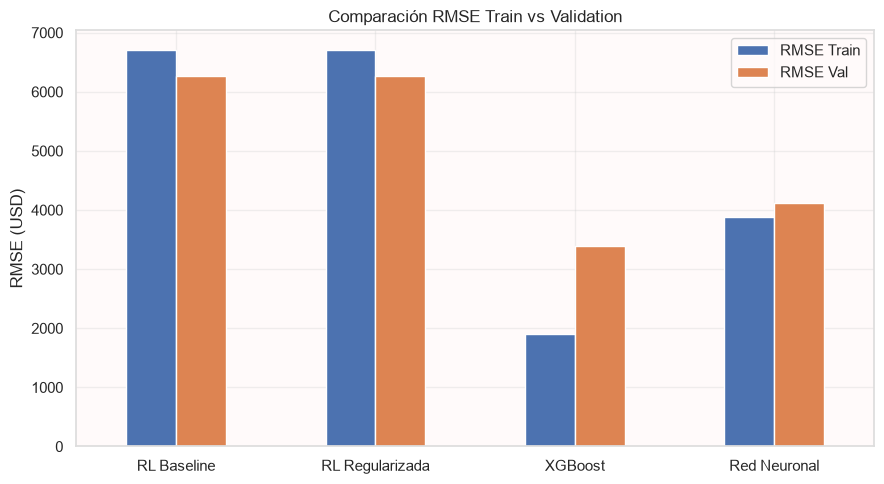

,Familia,Mejor modelo,RMSE Val
0,Regresión Lineal,Lasso (λ=1.0) + TF-IDF,6260.40814
1,XGBoost,XGBoost Categórico + TF-IDF,3395.87000
2,Red Neuronal,NN_256_128_relu,4116.22998


In [63]:
plot_rmse_train_val(comparacion_train_val)

display(pd.DataFrame({
    "Familia":[
        "Regresión Lineal",
        "XGBoost",
        "Red Neuronal"
    ],
    "Mejor modelo":[
        f"{mejor_rl_config['Modelo']} (λ={mejor_rl_config['Lambda']}) + TF-IDF",
        "XGBoost Categórico + TF-IDF",
        mejor_nn
    ],
    "RMSE Val":[
        rmse_rl_final,
        rmse_categorico_final,
        resultados_nn_no_desc.iloc[0]["RMSE (USD)"]
    ]
}))

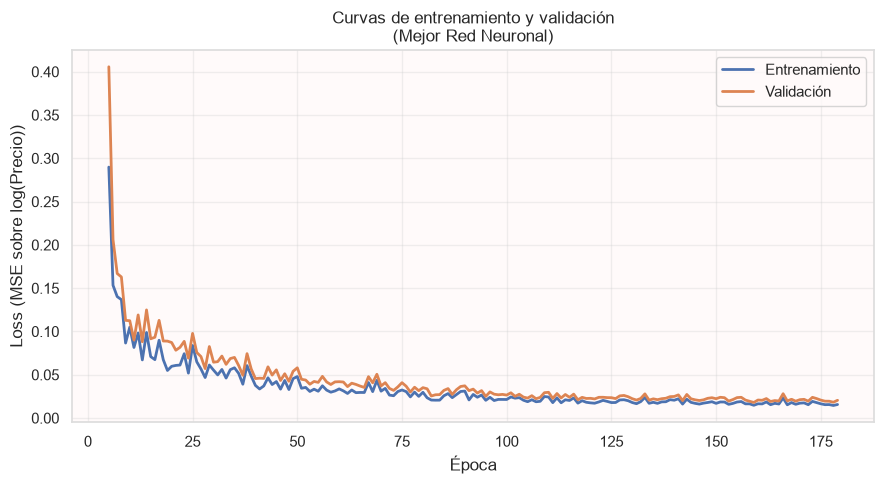

In [64]:
plot_curvas_entrenamiento(
    historiales_nn_no_desc[mejor_nn_no_desc],
    titulo="Curvas de entrenamiento y validación\n(Mejor Red Neuronal)"
)

Se observa que las curvas de entrenamiento y validación permanecen cercanas, lo que indica un entrenamiento estable y sin señales marcadas de sobreajuste.

### ***MODELO FINAL SELECCIONADO***

***Luego de comparar todos los modelos desarrollados, se seleccionó como modelo final XGBoost Categórico con TF-IDF, ya que obtuvo el menor RMSE y el mayor R² sobre el conjunto de validación. Este será el modelo utilizado para generar las predicciones sobre el conjunto de prueba provisto por la cátedra.***

In [65]:
mejor = resumen_final.sort_values("RMSE (USD)").head(1)

display(
    mejor.style
    .format({
        "RMSE (USD)": "{:.2f}",
        "MAE (USD)": "{:.2f}",
        "R²": "{:.4f}"
    })
)

print("\nEl modelo seleccionado será utilizado para generar las predicciones sobre el conjunto de prueba.")

,Modelo,RMSE (USD),MAE (USD),R²
6,XGBoost Categórico - Con TF-IDF,3395.87,2026.33,0.9560



El modelo seleccionado será utilizado para generar las predicciones sobre el conjunto de prueba.


### Modelo final

In [66]:
mejor_modelo = resumen_final.sort_values("RMSE (USD)").iloc[0]["Modelo"]

predicciones_finales = {
        'RL Base - Con TF-IDF': predicciones_rl_base,
        'RL Base - Sin TF-IDF': predicciones_rl_base_no_desc,
        f'RL {mejor_rl_config["Modelo"]} (λ = {mejor_rl_config["Lambda"]}) - Con TF-IDF': predicciones_rl_final,
        f'RL {mejor_no_desc["Modelo"]}: (λ = {mejor_no_desc["Lambda"]}) - Sin TF-IDF': predicciones_rl_no_desc_final,
        'Red Neuronal - Con TF-IDF': predicciones_nn[mejor_nn],
        'Red Neuronal - Sin TF-IDF': predicciones_nn_no_desc[mejor_nn],
        'XGBoost Categórico - Con TF-IDF': prediccion_categorico_final,
        'XGBoost Categórico - Sin TF-IDF': prediccion_categorico_final_no_desc,
        'XGBoost OHE - Con TF-IDF': prediccion_ohe_final,
        'XGBoost OHE - Sin TF-IDF': prediccion_ohe_final_no_desc,
}

mejores_predicciones = predicciones_finales[mejor_modelo]
pd.DataFrame({'Precio': mejores_predicciones}).to_csv(f'Gurevich_Otero_predictions_{mejor_modelo}.csv', index = False)

In [67]:
print(f"Modelo seleccionado: {mejor_modelo}")


Modelo seleccionado: XGBoost Categórico - Con TF-IDF
